# Informe de miniproyecto 2 - Curso Técnicas de Deep Learning

# Clasificación de Sentimientos de Reseñas de Películas en IMDb con RNN

## Microproyecto 2: Análisis de Sentimientos con Redes Neuronales Recurrentes

**Autor:** Microproyecto Deep Learning  
**Fecha:** Noviembre 2025  
**Objetivo:** Desarrollar un clasificador de sentimientos basado en RNN que permita categorizar reseñas de películas de IMDb como positivas (clase 1) o negativas (clase 0).

---

## Tabla de Contenidos

1. **Preprocesamiento de las Reseñas**
   - Carga y exploración de datos
   - Pipeline de limpieza
   - Tokenización y secuenciación
   - División del dataset

2. **Desarrollo de la Arquitectura RNN**
   - Justificación de la arquitectura
   - Construcción del modelo
   - Compilación

3. **Entrenamiento y Evaluación del Modelo**
   - Configuración de callbacks
   - Entrenamiento
   - Visualizaciones de desempeño
   - Métricas y análisis cualitativo

## Configuración de Hiperparámetros

En esta sección definimos todos los hiperparámetros clave del proyecto como **"perillas"** configurables. Esto facilita la experimentación y el ajuste del modelo sin necesidad de modificar el código en múltiples lugares.

**Justificación:** Centralizar los hiperparámetros en un solo lugar sigue el principio DRY (Don't Repeat Yourself) y facilita la reproducibilidad del experimento.

In [1]:
# ==========================================
# CONFIGURACIÓN DE HIPERPARÁMETROS
# ==========================================

CONFIG = {
    # === Preprocesamiento ===
    'MAX_VOCAB_SIZE': 10000,          # Tamaño máximo del vocabulario
    'MAX_SEQUENCE_LENGTH': 200,       # Longitud máxima de secuencias (en tokens)
    'TRAIN_SPLIT': 0.8,               # Proporción para entrenamiento (80%)
    'VAL_SPLIT': 0.1,                 # Proporción para validación (10%)
    'TEST_SPLIT': 0.1,                # Proporción para test (10%)
    'OOV_TOKEN': '<OOV>',             # Token para palabras fuera del vocabulario
    
    # === Word2Vec Parameters (NUEVO) ===
    'W2V_VECTOR_SIZE': 128,           # Dimensión de los embeddings Word2Vec
    'W2V_WINDOW': 5,                  # Ventana de contexto
    'W2V_MIN_COUNT': 2,               # Frecuencia mínima de palabras
    'W2V_WORKERS': 4,                 # Hilos paralelos para entrenamiento
    'W2V_EPOCHS': 10,                 # Épocas para entrenar Word2Vec
    'W2V_SG': 0,                      # 0=CBOW, 1=Skip-gram
    'W2V_TRAINABLE': False,           # Si los embeddings son entrenables en RNN
    
    # === Arquitectura del Modelo ===
    'EMBEDDING_DIM': 128,             # Dimensión de los embeddings (debe coincidir con W2V_VECTOR_SIZE)
    'LSTM_UNITS': 128,                # Unidades en la capa LSTM (aumentado de 64 a 128)
    'LSTM_UNITS_2': 64,               # Unidades en la segunda capa LSTM
    'BIDIRECTIONAL': True,            # Usar LSTM bidireccional
    'SPATIAL_DROPOUT': 0.2,           # Dropout espacial en embeddings
    'DROPOUT_RATE': 0.3,              # Dropout en capas densas
    'DENSE_UNITS': 32,                # Unidades en capa densa oculta
    'L2_REGULARIZATION': 0.01,        # Factor de regularización L2
    'USE_BATCH_NORM': True,           # Usar Batch Normalization
    'STACKED_LSTM': True,             # Usar arquitectura de LSTM apilado
    
    # === Entrenamiento ===
    'BATCH_SIZE': 32,                 # Tamaño del batch
    'EPOCHS': 30,                     # Número máximo de épocas
    'LEARNING_RATE': 1.45e-03,        # Tasa de aprendizaje
    'VALIDATION_SPLIT': 0.0,          # Usaremos validación manual
    
    # === Callbacks ===
    'PATIENCE_EARLY_STOP': 3,         # Paciencia para early stopping
    'PATIENCE_REDUCE_LR': 2,          # Paciencia para reducir learning rate
    'REDUCE_LR_FACTOR': 0.5,          # Factor de reducción del LR
    'MIN_LR': 1e-7,                   # Learning rate mínimo
    
    # === Otros ===
    'RANDOM_SEED': 42,                # Semilla para reproducibilidad
    'VERBOSE': 1,                     # Nivel de verbosidad
    
    # === Rutas de archivos ===
    'DATA_PATH': 'movie.csv',
    'MODEL_SAVE_PATH': 'sentiment_rnn_w2v_model.keras',      
    'TOKENIZER_SAVE_PATH': 'tokenizer_w2v.pickle',           
    'W2V_MODEL_PATH': 'word2vec_model.model',                
    'CONFIG_SAVE_PATH': 'model_config_w2v.json',             
    'HISTORY_SAVE_PATH': 'training_history_w2v.pickle',      
}

# Validar consistencia (NUEVO)
assert CONFIG['EMBEDDING_DIM'] == CONFIG['W2V_VECTOR_SIZE'], \
    "EMBEDDING_DIM debe coincidir con W2V_VECTOR_SIZE"

# Mapeo de clases
CLASS_NAMES = {0: 'Negative', 1: 'Positive'}

print("Configuración actualizada para Word2Vec")
print(f"Dataset splits: Train={CONFIG['TRAIN_SPLIT']*100}%, Val={CONFIG['VAL_SPLIT']*100}%, Test={CONFIG['TEST_SPLIT']*100}%")
print(f"Dimensión de embeddings Word2Vec: {CONFIG['W2V_VECTOR_SIZE']}")
print(f"Embeddings entrenables: {CONFIG['W2V_TRAINABLE']}")

Configuración actualizada para Word2Vec
Dataset splits: Train=80.0%, Val=10.0%, Test=10.0%
Dimensión de embeddings Word2Vec: 128
Embeddings entrenables: False


---

# CAPÍTULO 1: PREPROCESAMIENTO DE LAS RESEÑAS

## 1.1 Importación de Librerías

In [2]:
!pip install gensim


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

# Manejo de datos
import pandas as pd
import numpy as np
import json
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento de texto
import re
from typing import List, Tuple, Dict
from collections import Counter

# Word2Vec (NUEVO)
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, 
    Dropout, SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

# Métricas y evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_curve, auc, roc_auc_score
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos - Updated for newer matplotlib versions
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('default')
sns.set_palette("husl")

# Configurar semilla para reproducibilidad
np.random.seed(CONFIG['RANDOM_SEED'])
tf.random.set_seed(CONFIG['RANDOM_SEED'])

print("Librerías importadas correctamente (con Word2Vec)")
print(f"TensorFlow version: {tf.__version__}")
print(f"Gensim disponible para Word2Vec")

Librerías importadas correctamente (con Word2Vec)
TensorFlow version: 2.9.1
Gensim disponible para Word2Vec


## 1.2 Carga y Exploración de Datos

Este código carga el archivo de datos indicado en la configuración (`movie.csv`) dentro de un DataFrame de Pandas y luego imprime un resumen exploratorio del dataset para verificar su calidad y estructura.
Muestra el número de filas y columnas, los nombres de las columnas, los tipos de datos de cada columna, la cantidad de valores nulos, la distribución de etiquetas de la variable objetivo y su proporción balanceada o desbalanceada. Finalmente, muestra las primeras tres filas del dataset para inspeccionar visualmente su contenido.

In [4]:
# ==========================================
# CARGA DE DATOS
# ==========================================

# Try to load the dataset, if not found, use IMDB dataset or download it
import os

if os.path.exists(CONFIG['DATA_PATH']):
    # Cargar el dataset
    df = pd.read_csv(CONFIG['DATA_PATH'])
else:
    print(f" Archivo '{CONFIG['DATA_PATH']}' no encontrado.")
    print(" Intentando cargar el dataset IMDB integrado de Keras...")
    
    # Load IMDB dataset from Keras
    from tensorflow.keras.datasets import imdb
    
    # Get word index
    word_index = imdb.get_word_index()
    reverse_word_index = {v: k for k, v in word_index.items()}
    
    # Load the dataset
    (train_data, train_labels), (test_data, test_labels) = imdb.load_data()
    
    # Function to decode reviews
    def decode_review(encoded_review):
        return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])
    
    # Decode all reviews
    all_reviews = []
    all_labels = []
    
    print("Decodificando reseñas del dataset IMDB...")
    for review in train_data:
        all_reviews.append(decode_review(review))
        
    for review in test_data:
        all_reviews.append(decode_review(review))
    
    all_labels = list(train_labels) + list(test_labels)
    
    # Create DataFrame
    df = pd.DataFrame({
        'text': all_reviews,
        'label': all_labels
    })
    
    print(f" Dataset IMDB cargado exitosamente!")
    print(f"   Total de {len(df)} reseñas")

# Información básica del dataset
print("="*60)
print(" INFORMACIÓN DEL DATASET")
print("="*60)
print(f"\n Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n Columnas: {list(df.columns)}")
print(f"\n Tipos de datos:\n{df.dtypes}")
print(f"\n Valores nulos:\n{df.isnull().sum()}")
print(f"\n Distribución de clases:\n{df['label'].value_counts()}")
print(f"\n Proporción de clases:\n{df['label'].value_counts(normalize=True)}")

# Mostrar primeras filas
print("\n" + "="*60)
print(" PRIMERAS 3 RESEÑAS DEL DATASET")
print("="*60)
display(df.head(3))

 Archivo 'movie.csv' no encontrado.
 Intentando cargar el dataset IMDB integrado de Keras...
Decodificando reseñas del dataset IMDB...
 Dataset IMDB cargado exitosamente!
   Total de 50000 reseñas
 INFORMACIÓN DEL DATASET

 Dimensiones: 50000 filas × 2 columnas

 Columnas: ['text', 'label']

 Tipos de datos:
text     object
label     int64
dtype: object

 Valores nulos:
text     0
label    0
dtype: int64

 Distribución de clases:
1    25000
0    25000
Name: label, dtype: int64

 Proporción de clases:
1    0.5
0    0.5
Name: label, dtype: float64

 PRIMERAS 3 RESEÑAS DEL DATASET


,text,label
0,? this film was just brilliant casting locatio...,1
1,? big hair big boobs bad music and a giant saf...,0
2,? this has to be one of the worst films of the...,0


## 1.3 Análisis Exploratorio de Datos (EDA)

Las visualizaciones nos ayudan a entender mejor:
- **Distribución de clases**: Para identificar si existe desbalance
- **Longitud de reseñas**: Para determinar un valor adecuado de `MAX_SEQUENCE_LENGTH`
- **Patrones en los datos**: Para detectar outliers o anomalías

Realiza un análisis exploratorio de reseñas: visualiza distribución de clases, longitud de textos en palabras, compara longitudes por sentimiento y muestra estadísticas descriptivas. Proporciona insights sobre balance del dataset y características de las reseñas.

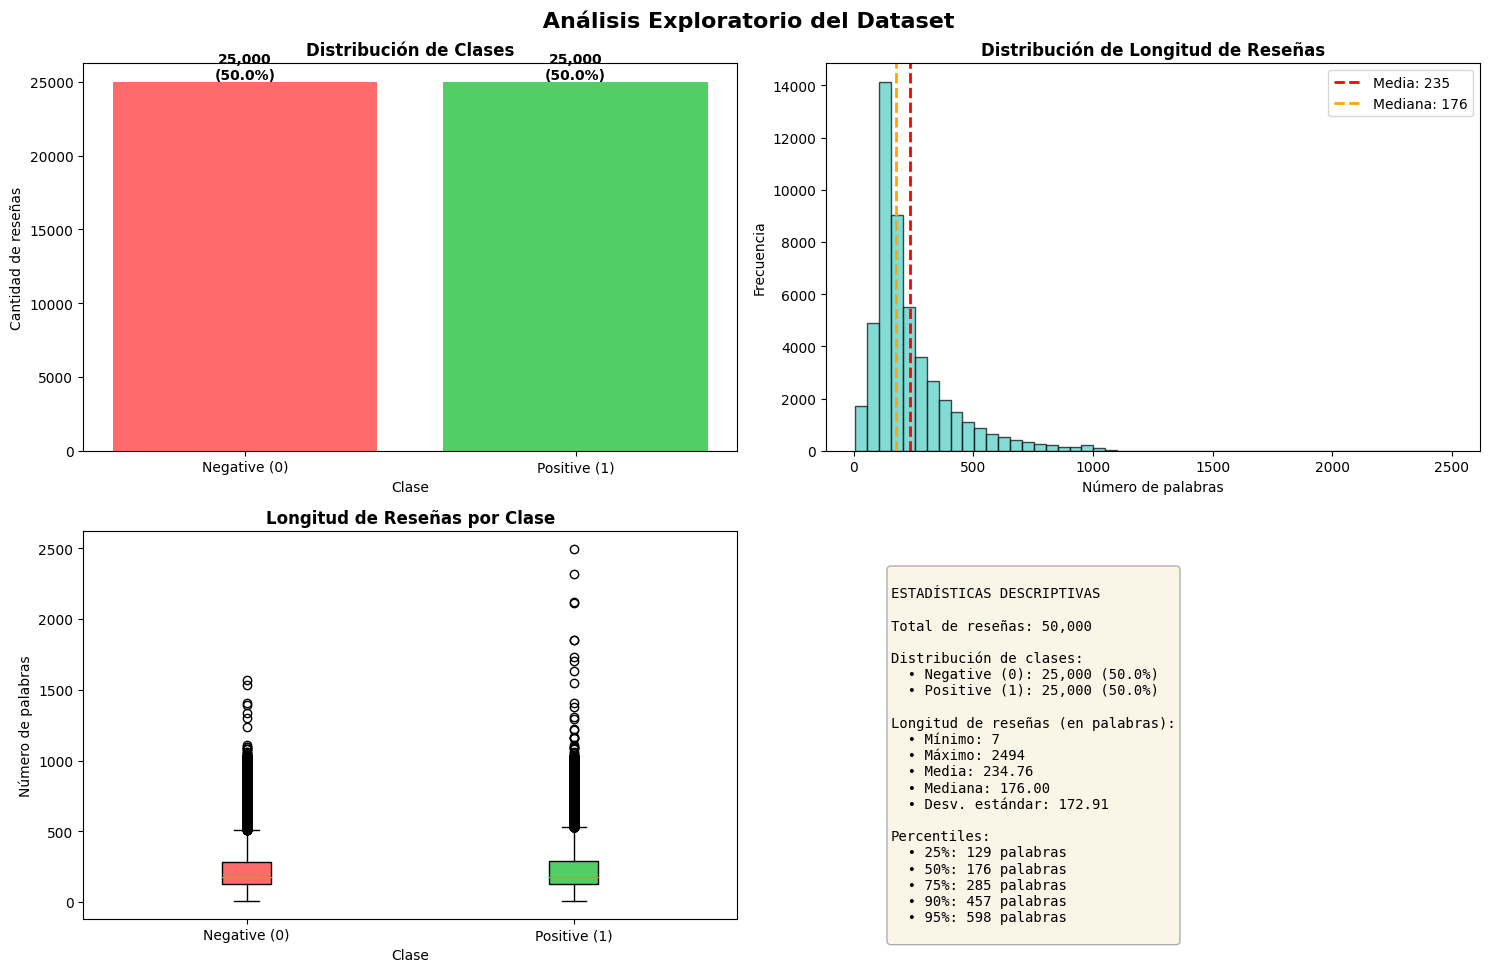


 Análisis exploratorio completado


In [5]:
# ==========================================
# ANÁLISIS EXPLORATORIO DE DATOS
# ==========================================

# Calcular longitud de reseñas (en palabras)
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))

# Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(' Análisis Exploratorio del Dataset', fontsize=16, fontweight='bold')

# 1. Distribución de clases
ax1 = axes[0, 0]
class_counts = df['label'].value_counts()
bars = ax1.bar(['Negative (0)', 'Positive (1)'], class_counts.values, color=['#ff6b6b', '#51cf66'])
ax1.set_title('Distribución de Clases', fontweight='bold')
ax1.set_ylabel('Cantidad de reseñas')
ax1.set_xlabel('Clase')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# 2. Distribución de longitud de reseñas
ax2 = axes[0, 1]
ax2.hist(df['review_length'], bins=50, color='#4ecdc4', edgecolor='black', alpha=0.7)
ax2.axvline(df['review_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["review_length"].mean():.0f}')
ax2.axvline(df['review_length'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df["review_length"].median():.0f}')
ax2.set_title('Distribución de Longitud de Reseñas', fontweight='bold')
ax2.set_xlabel('Número de palabras')
ax2.set_ylabel('Frecuencia')
ax2.legend()

# 3. Boxplot de longitud por clase
ax3 = axes[1, 0]
data_to_plot = [df[df['label']==0]['review_length'], df[df['label']==1]['review_length']]
bp = ax3.boxplot(data_to_plot, labels=['Negative (0)', 'Positive (1)'], patch_artist=True)
bp['boxes'][0].set_facecolor('#ff6b6b')
bp['boxes'][1].set_facecolor('#51cf66')
ax3.set_title('Longitud de Reseñas por Clase', fontweight='bold')
ax3.set_ylabel('Número de palabras')
ax3.set_xlabel('Clase')

# 4. Estadísticas descriptivas
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = f"""
ESTADÍSTICAS DESCRIPTIVAS

Total de reseñas: {len(df):,}

Distribución de clases:
  • Negative (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)
  • Positive (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)

Longitud de reseñas (en palabras):
  • Mínimo: {df['review_length'].min():.0f}
  • Máximo: {df['review_length'].max():.0f}
  • Media: {df['review_length'].mean():.2f}
  • Mediana: {df['review_length'].median():.2f}
  • Desv. estándar: {df['review_length'].std():.2f}
  
Percentiles:
  • 25%: {df['review_length'].quantile(0.25):.0f} palabras
  • 50%: {df['review_length'].quantile(0.50):.0f} palabras
  • 75%: {df['review_length'].quantile(0.75):.0f} palabras
  • 90%: {df['review_length'].quantile(0.90):.0f} palabras
  • 95%: {df['review_length'].quantile(0.95):.0f} palabras
"""
ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print(f"\n Análisis exploratorio completado")

## 1.4 Pipeline de Preprocesamiento de Texto

Este código define una clase llamada TextPreprocessor que encapsula todo el proceso de limpieza de texto para reseñas de películas siguiendo el principio de responsabilidad única. La clase incluye métodos privados para eliminar etiquetas HTML, remover caracteres especiales y normalizar espacios en blanco, y un método principal clean_text que aplica este pipeline completo a un texto individual. También incluye clean_corpus, que permite limpiar múltiples textos de forma eficiente, mostrando progreso si se desea.
Finalmente, se crea una instancia configurada para convertir el texto a minúsculas, eliminar HTML y remover caracteres especiales.

In [6]:
# ==========================================
# CLASE TEXTPREPROCESSOR
# ==========================================

class TextPreprocessor:
    """
    Clase para preprocesar texto de reseñas de películas.
    
    Esta clase sigue el principio de Single Responsibility (SOLID) y encapsula
    toda la lógica de limpieza de texto en un solo lugar (DRY).
    
    Attributes:
        lowercase (bool): Si se debe convertir el texto a minúsculas.
        remove_html (bool): Si se deben eliminar tags HTML.
        remove_special_chars (bool): Si se deben eliminar caracteres especiales.
    
    Methods:
        clean_text: Limpia un texto individual.
        clean_corpus: Limpia un conjunto completo de textos.
    
    Example:
        >>> preprocessor = TextPreprocessor()
        >>> clean = preprocessor.clean_text("<br />Great movie!")
        >>> print(clean)
        'great movie'
    """
    
    def __init__(
        self, 
        lowercase: bool = True,
        remove_html: bool = True,
        remove_special_chars: bool = True
    ):
        """
        Inicializa el preprocesador de texto.
        
        Args:
            lowercase: Si se debe convertir a minúsculas.
            remove_html: Si se deben eliminar tags HTML.
            remove_special_chars: Si se deben eliminar caracteres especiales.
        """
        self.lowercase = lowercase
        self.remove_html = remove_html
        self.remove_special_chars = remove_special_chars
    
    def _remove_html_tags(self, text: str) -> str:
        """
        Elimina tags HTML del texto.
        
        Args:
            text: Texto con posibles tags HTML.
            
        Returns:
            Texto sin tags HTML.
        """
        clean = re.compile('<.*?>')
        return re.sub(clean, ' ', text)
    
    def _remove_special_characters(self, text: str) -> str:
        """
        Elimina caracteres especiales, manteniendo solo letras, números y espacios.
        
        Args:
            text: Texto original.
            
        Returns:
            Texto sin caracteres especiales.
        """
        # Mantener solo letras, números y espacios
        pattern = r'[^a-zA-Z0-9\s]'
        return re.sub(pattern, ' ', text)
    
    def _remove_extra_whitespace(self, text: str) -> str:
        """
        Elimina espacios en blanco adicionales.
        
        Args:
            text: Texto con posibles espacios extra.
            
        Returns:
            Texto con espacios normalizados.
        """
        return ' '.join(text.split())
    
    def clean_text(self, text: str) -> str:
        """
        Aplica el pipeline completo de limpieza a un texto.
        
        Args:
            text: Texto original a limpiar.
            
        Returns:
            Texto limpio y preprocesado.
        """
        if pd.isna(text):
            return ""
        
        text = str(text)
        
        # 1. Eliminar HTML tags
        if self.remove_html:
            text = self._remove_html_tags(text)
        
        # 2. Convertir a minúsculas
        if self.lowercase:
            text = text.lower()
        
        # 3. Eliminar caracteres especiales
        if self.remove_special_chars:
            text = self._remove_special_characters(text)
        
        # 4. Eliminar espacios extras
        text = self._remove_extra_whitespace(text)
        
        return text
    
    def clean_corpus(self, texts: List[str], verbose: bool = True) -> List[str]:
        """
        Limpia un conjunto completo de textos.
        
        Args:
            texts: Lista de textos a limpiar.
            verbose: Si se debe mostrar progreso.
            
        Returns:
            Lista de textos limpios.
        """
        if verbose:
            print(f" Limpiando {len(texts):,} textos...")
        
        cleaned_texts = [self.clean_text(text) for text in texts]
        
        if verbose:
            print(f" Limpieza completada")
        
        return cleaned_texts


# Crear instancia del preprocesador
preprocessor = TextPreprocessor(
    lowercase=True,
    remove_html=True,
    remove_special_chars=True
)

print(" Clase TextPreprocessor creada correctamente")

 Clase TextPreprocessor creada correctamente


## 1.3 Clase Word2VecHandler

Este código define la clase `Word2VecHandler`, cuyo propósito es **gestionar todo el ciclo de vida de un modelo Word2Vec**, desde el entrenamiento hasta su integración con una red neuronal en Keras. La clase se responsabiliza únicamente de los embeddings, aplicando buenas prácticas de diseño como Single Responsibility y Open/Closed.

Dentro de la clase, se incluyen métodos que:

* **Tokenizan el texto** en formato compatible con Word2Vec (`_tokenize_for_w2v`).
* **Entrenan un modelo Word2Vec** sobre el corpus (`train`), permitiendo ajustar parámetros como ventana, dimensión, frecuencia mínima, tipo de arquitectura (CBOW o Skip-gram), número de épocas y hilos paralelos.
* **Construyen una matriz de embeddings** (`create_embedding_matrix`) que Keras usará en su capa `Embedding`.
  Esta matriz asigna a cada palabra un vector proveniente del modelo Word2Vec, y cuando la palabra no existe en el vocabulario, se asigna un vector aleatorio. También muestra estadísticas de cobertura del vocabulario.
* **Guardan y cargan el modelo** Word2Vec (`save_model` y `load_model`) para reutilización.
* **Obtienen palabras similares** según la vecindad semántica aprendida (`get_most_similar`), útil para análisis interpretativo del embedding.

Al final, se imprime un mensaje confirmando que la clase fue creada correctamente.


In [7]:
# ==========================================
# CLASE WORD2VEC HANDLER
# ==========================================

class Word2VecHandler:
    """
    Clase para entrenar y gestionar modelos Word2Vec.
    
    Responsabilidades:
    - Entrenar modelo Word2Vec en corpus de textos
    - Crear matriz de embeddings para Keras
    - Convertir textos a secuencias usando vocabulario Word2Vec
    
    Principios aplicados:
    - Single Responsibility: Solo maneja embeddings Word2Vec
    - Dependency Inversion: Depende de abstracciones (Tokenizer)
    - Open/Closed: Extensible para diferentes configuraciones
    """
    
    def __init__(
        self,
        vector_size: int = 128,
        window: int = 5,
        min_count: int = 2,
        workers: int = 4,
        epochs: int = 10,
        sg: int = 0,
        seed: int = 42
    ):
        """
        Inicializa el handler de Word2Vec.
        
        Args:
            vector_size: Dimensión de vectores (debe coincidir con EMBEDDING_DIM)
            window: Ventana de contexto para capturar relaciones
            min_count: Frecuencia mínima de palabras (filtro de ruido)
            workers: Hilos paralelos (acelera entrenamiento)
            epochs: Iteraciones sobre el corpus
            sg: 0 para CBOW (rápido), 1 para Skip-gram (mejor calidad)
            seed: Semilla para reproducibilidad
        """
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.epochs = epochs
        self.sg = sg
        self.seed = seed
        self.w2v_model = None
    
    def _tokenize_for_w2v(self, texts: List[str]) -> List[List[str]]:
        """
        Tokeniza textos para Word2Vec usando Gensim.
        
        Args:
            texts: Lista de textos limpios
            
        Returns:
            Lista de listas de tokens (formato requerido por Word2Vec)
        """
        return [simple_preprocess(text, deacc=True) for text in texts]
    
    def train(self, texts: List[str], verbose: bool = True) -> None:
        """
        Entrena modelo Word2Vec en el corpus.
        
        Args:
            texts: Textos de entrenamiento (ya preprocesados)
            verbose: Si mostrar progreso
        """
        if verbose:
            print("Entrenando modelo Word2Vec...")
            print(f"  Vector size: {self.vector_size}")
            print(f"  Window: {self.window}")
            print(f"  Min count: {self.min_count}")
            print(f"  Algorithm: {'Skip-gram' if self.sg else 'CBOW'}")
            print(f"  Epochs: {self.epochs}")
        
        # Tokenizar textos
        tokenized_texts = self._tokenize_for_w2v(texts)
        
        # Entrenar Word2Vec
        self.w2v_model = Word2Vec(
            sentences=tokenized_texts,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            sg=self.sg,
            seed=self.seed,
            epochs=self.epochs
        )
        
        if verbose:
            vocab_size = len(self.w2v_model.wv)
            print(f"\nModelo Word2Vec entrenado")
            print(f"  Vocabulario: {vocab_size:,} palabras")
            print(f"  Total de tokens procesados: {self.w2v_model.corpus_total_words:,}")
    
    def create_embedding_matrix(
        self, 
        tokenizer: Tokenizer, 
        max_vocab_size: int = None
    ) -> np.ndarray:
        """
        Crea matriz de embeddings para Keras desde Word2Vec.
        
        Esta matriz será usada como pesos iniciales en la capa Embedding.
        Mapea índices del Tokenizer de Keras a vectores de Word2Vec.
        
        Args:
            tokenizer: Tokenizer de Keras con vocabulario
            max_vocab_size: Tamaño máximo del vocabulario
            
        Returns:
            Matriz numpy de shape (vocab_size, vector_size)
            
        Note:
            Palabras no encontradas en Word2Vec se inicializan con vectores aleatorios
        """
        if self.w2v_model is None:
            raise ValueError("Debe entrenar el modelo Word2Vec primero")
        
        # Determinar tamaño del vocabulario
        vocab_size = len(tokenizer.word_index) + 1  # +1 para índice 0 (padding)
        if max_vocab_size is not None:
            vocab_size = min(vocab_size, max_vocab_size)
        
        # Inicializar matriz con vectores aleatorios pequeños
        embedding_matrix = np.random.uniform(
            low=-0.05, 
            high=0.05, 
            size=(vocab_size, self.vector_size)
        )
        
        # Vector cero para padding (índice 0)
        embedding_matrix[0] = np.zeros(self.vector_size)
        
        # Llenar matriz con vectores de Word2Vec
        words_found = 0
        for word, idx in tokenizer.word_index.items():
            if idx >= vocab_size:
                continue
            
            try:
                embedding_vector = self.w2v_model.wv[word]
                embedding_matrix[idx] = embedding_vector
                words_found += 1
            except KeyError:
                # Palabra no está en Word2Vec, mantener inicialización aleatoria
                pass
        
        coverage = (words_found / vocab_size) * 100
        print(f"\nMatriz de embeddings creada:")
        print(f"  Shape: {embedding_matrix.shape}")
        print(f"  Palabras encontradas en W2V: {words_found}/{vocab_size} ({coverage:.2f}%)")
        print(f"  Palabras con vectores aleatorios: {vocab_size - words_found}")
        
        return embedding_matrix
    
    def save_model(self, filepath: str) -> None:
        """Guarda el modelo Word2Vec entrenado."""
        if self.w2v_model is None:
            raise ValueError("No hay modelo para guardar")
        self.w2v_model.save(filepath)
        print(f"Modelo Word2Vec guardado en: {filepath}")
    
    def load_model(self, filepath: str) -> None:
        """Carga un modelo Word2Vec previamente entrenado."""
        self.w2v_model = Word2Vec.load(filepath)
        print(f"Modelo Word2Vec cargado desde: {filepath}")
    
    def get_most_similar(self, word: str, topn: int = 5) -> List[Tuple[str, float]]:
        """
        Encuentra palabras más similares (útil para análisis exploratorio).
        
        Args:
            word: Palabra de consulta
            topn: Número de palabras similares a retornar
            
        Returns:
            Lista de tuplas (palabra, similitud)
        """
        if self.w2v_model is None:
            raise ValueError("Debe entrenar o cargar el modelo primero")
        
        try:
            return self.w2v_model.wv.most_similar(word, topn=topn)
        except KeyError:
            return []


print("Clase Word2VecHandler creada correctamente")

Clase Word2VecHandler creada correctamente


## 1.6 Aplicación del Preprocesamiento al Dataset Completo

Este código aplica el proceso de limpieza de texto a todas las reseñas del dataset usando la instancia de `TextPreprocessor`.
Primero muestra cuántas reseñas serán procesadas. Luego genera una nueva columna llamada `cleaned_text` que contiene las reseñas ya limpiadas (sin HTML, en minúsculas y sin caracteres especiales).
Después verifica si como resultado del preprocesamiento alguna reseña quedó vacía y, en caso afirmativo, elimina esas filas para evitar problemas durante el entrenamiento del modelo.
Finalmente imprime un mensaje de confirmación indicando que el preprocesamiento se completó y muestra el número total de reseñas resultantes en el dataset.


In [8]:
# ==========================================
# PREPROCESAMIENTO DEL DATASET COMPLETO
# ==========================================

print(" Aplicando preprocesamiento a todo el dataset...")
print(f" Total de reseñas: {len(df):,}\n")

# Aplicar limpieza a todas las reseñas
df['cleaned_text'] = preprocessor.clean_corpus(df['text'].values, verbose=True)

# Verificar que no hay valores vacíos después de la limpieza
empty_reviews = df['cleaned_text'].str.strip().eq('').sum()
if empty_reviews > 0:
    print(f"  Se encontraron {empty_reviews} reseñas vacías después de la limpieza")
    # Eliminar reseñas vacías
    df = df[df['cleaned_text'].str.strip() != '']
    print(f" Reseñas vacías eliminadas. Nuevo tamaño: {len(df):,}")

print(f"\n Preprocesamiento aplicado correctamente")
print(f" Total de reseñas procesadas: {len(df):,}")

 Aplicando preprocesamiento a todo el dataset...
 Total de reseñas: 50,000

 Limpiando 50,000 textos...
 Limpieza completada

 Preprocesamiento aplicado correctamente
 Total de reseñas procesadas: 50,000


## 1.7 División del Dataset (Train/Validation/Test)

- **Training set (80%)**: Conjunto principal para entrenar el modelo
- **Validation set (10%)**: Para ajustar hiperparámetros y detectar overfitting durante el entrenamiento
- **Test set (10%)**: Para evaluación final del modelo con datos completamente no vistos

Esta división permite evaluar el modelo de forma robusta y evitar sesgos en la evaluación final.

In [9]:
# ==========================================
# DIVISIÓN DEL DATASET
# ==========================================

# Extraer textos y etiquetas
texts = df['cleaned_text'].values
labels = df['label'].values

print(" DIVISIÓN DEL DATASET")
print("="*60)

# Primera división: separar test set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, 
    labels, 
    test_size=CONFIG['TEST_SPLIT'],
    random_state=CONFIG['RANDOM_SEED'],
    stratify=labels
)

# Segunda división: separar train y validation del 90% restante
# Validation = 10% del total = 10/90 = 0.111 del temp
val_size_from_temp = CONFIG['VAL_SPLIT'] / (CONFIG['TRAIN_SPLIT'] + CONFIG['VAL_SPLIT'])

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_size_from_temp,
    random_state=CONFIG['RANDOM_SEED'],
    stratify=y_temp
)

y_train = np.array(y_train, dtype='float32')
y_val = np.array(y_val, dtype='float32')
y_test = np.array(y_test, dtype='float32')

# Validar datos nulos antes de procesar:
assert df.isnull().sum().sum() == 0, "Datos nulos detectados"
# Información de la división
print(f"\n Tamaños de los conjuntos:")
print(f"   • Training set:   {len(X_train):,} muestras ({len(X_train)/len(texts)*100:.1f}%)")
print(f"   • Validation set: {len(X_val):,} muestras ({len(X_val)/len(texts)*100:.1f}%)")
print(f"   • Test set:       {len(X_test):,} muestras ({len(X_test)/len(texts)*100:.1f}%)")
print(f"   • Total:          {len(texts):,} muestras")

print(f"\n Dataset dividido correctamente")

 DIVISIÓN DEL DATASET

 Tamaños de los conjuntos:
   • Training set:   40,000 muestras (80.0%)
   • Validation set: 5,000 muestras (10.0%)
   • Test set:       5,000 muestras (10.0%)
   • Total:          50,000 muestras

 Dataset dividido correctamente


## 1.8 Entrenamiento de Word2Vec

Este código entrena el modelo Word2Vec utilizando únicamente el conjunto de entrenamiento (`X_train`) para evitar filtración de información entre entrenamiento y validación/test (data leakage).
Primero crea una instancia de `Word2VecHandler` usando los hiperparámetros definidos en la configuración, luego ejecuta el método `train` para aprender los vectores distribucionales del lenguaje sobre las reseñas ya preprocesadas.
Después, guarda el modelo entrenado en disco para reutilizarlo en futuras ejecuciones.
Finalmente, realiza un análisis exploratorio mostrando las palabras más similares a algunas palabras de prueba, lo que permite interpretar la calidad del embedding aprendido.
Cierra con un mensaje confirmando que el entrenamiento fue exitoso.


In [10]:
# ==========================================
# ENTRENAMIENTO DE WORD2VEC
# ==========================================

print("="*60)
print("ENTRENAMIENTO DE WORD2VEC")
print("="*60)

# Crear instancia del handler
w2v_handler = Word2VecHandler(
    vector_size=CONFIG['W2V_VECTOR_SIZE'],
    window=CONFIG['W2V_WINDOW'],
    min_count=CONFIG['W2V_MIN_COUNT'],
    workers=CONFIG['W2V_WORKERS'],
    epochs=CONFIG['W2V_EPOCHS'],
    sg=CONFIG['W2V_SG'],
    seed=CONFIG['RANDOM_SEED']
)

# Entrenar SOLO en training set (evitar data leakage)
w2v_handler.train(X_train, verbose=True)

# Guardar modelo Word2Vec
w2v_handler.save_model(CONFIG['W2V_MODEL_PATH'])

# Análisis exploratorio opcional
print("\n" + "="*60)
print("ANÁLISIS DE WORD2VEC - PALABRAS SIMILARES")
print("="*60)

test_words = ['good', 'bad', 'excellent', 'terrible', 'boring']
for word in test_words:
    similar = w2v_handler.get_most_similar(word, topn=3)
    if similar:
        print(f"\n'{word}' -> {[w for w, _ in similar]}")
    else:
        print(f"\n'{word}' -> No encontrada en vocabulario")

print("\n" + "="*60)
print("Word2Vec entrenado correctamente")
print("="*60)

ENTRENAMIENTO DE WORD2VEC
Entrenando modelo Word2Vec...
  Vector size: 128
  Window: 5
  Min count: 2
  Algorithm: CBOW
  Epochs: 10

Modelo Word2Vec entrenado
  Vocabulario: 50,251 palabras
  Total de tokens procesados: 8,876,591
Modelo Word2Vec guardado en: word2vec_model.model

ANÁLISIS DE WORD2VEC - PALABRAS SIMILARES

'good' -> ['decent', 'bad', 'great']

'bad' -> ['terrible', 'good', 'horrible']

'excellent' -> ['outstanding', 'exceptional', 'superb']

'terrible' -> ['horrible', 'awful', 'atrocious']

'boring' -> ['dull', 'tedious', 'pointless']

Word2Vec entrenado correctamente


## 1.8 Tokenización y Creación de Secuencias

- **Conversión a números**: Las RNN solo procesan números, no texto directo
- **Vocabulario limitado**: Usar `MAX_VOCAB_SIZE` para controlar el tamaño del modelo
- **OOV Token**: Manejar palabras fuera del vocabulario con un token especial
- **Padding**: Todas las secuencias deben tener la misma longitud (`MAX_SEQUENCE_LENGTH`)

**Proceso:**
1. Crear tokenizer y ajustarlo solo con el training set (evitar data leakage)
2. Convertir textos a secuencias de enteros
3. Aplicar padding para longitud uniforme

In [11]:
# ==========================================
# TOKENIZACIÓN Y SECUENCIACIÓN CON WORD2VEC
# ==========================================

print("TOKENIZACIÓN Y CREACIÓN DE SECUENCIAS")
print("="*60)

# Crear el tokenizer
tokenizer = Tokenizer(
    num_words=CONFIG['MAX_VOCAB_SIZE'],
    oov_token=CONFIG['OOV_TOKEN'],
    lower=True
)

# Ajustar el tokenizer SOLO con el training set (evitar data leakage)
tokenizer.fit_on_texts(X_train)

# Convertir textos a secuencias
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Aplicar padding
X_train_padded = pad_sequences(
    X_train_seq, 
    maxlen=CONFIG['MAX_SEQUENCE_LENGTH'], 
    padding='post', 
    truncating='post'
)
X_val_padded = pad_sequences(
    X_val_seq, 
    maxlen=CONFIG['MAX_SEQUENCE_LENGTH'], 
    padding='post', 
    truncating='post'
)
X_test_padded = pad_sequences(
    X_test_seq, 
    maxlen=CONFIG['MAX_SEQUENCE_LENGTH'], 
    padding='post', 
    truncating='post'
)

# Información del vocabulario
vocab_size = len(tokenizer.word_index) + 1  # +1 para el índice 0
actual_vocab_size = min(vocab_size, CONFIG['MAX_VOCAB_SIZE'])

print(f"\nInformación del Vocabulario:")
print(f"  Palabras únicas encontradas: {len(tokenizer.word_index):,}")
print(f"  Tamaño del vocabulario (con límite): {actual_vocab_size:,}")
print(f"  Token OOV: '{CONFIG['OOV_TOKEN']}' (índice: {tokenizer.word_index[CONFIG['OOV_TOKEN']]})")

# NUEVO: Crear matriz de embeddings desde Word2Vec
print("\n" + "="*60)
print("CREANDO MATRIZ DE EMBEDDINGS DESDE WORD2VEC")
print("="*60)

embedding_matrix = w2v_handler.create_embedding_matrix(
    tokenizer=tokenizer,
    max_vocab_size=CONFIG['MAX_VOCAB_SIZE']
)

print(f"\nDimensiones de los conjuntos tokenizados:")
print(f"  X_train: {X_train_padded.shape}")
print(f"  X_val:   {X_val_padded.shape}")
print(f"  X_test:  {X_test_padded.shape}")

print(f"\nTokenización completada correctamente")

TOKENIZACIÓN Y CREACIÓN DE SECUENCIAS

Información del Vocabulario:
  Palabras únicas encontradas: 69,779
  Tamaño del vocabulario (con límite): 10,000
  Token OOV: '<OOV>' (índice: 1)

CREANDO MATRIZ DE EMBEDDINGS DESDE WORD2VEC

Matriz de embeddings creada:
  Shape: (10000, 128)
  Palabras encontradas en W2V: 9801/10000 (98.01%)
  Palabras con vectores aleatorios: 199

Dimensiones de los conjuntos tokenizados:
  X_train: (40000, 200)
  X_val:   (5000, 200)
  X_test:  (5000, 200)

Tokenización completada correctamente


---

#  CAPÍTULO 2: DESARROLLO DE LA ARQUITECTURA RNN

## 2.1 Arquitectura Propuesta

### **Arquitectura seleccionada: Bidirectional LSTM con Embeddings (Word2Vec)**

La arquitectura propuesta se basa en una red recurrente del tipo **Bidirectional LSTM (Long Short-Term Memory)**, diseñada para el análisis de sentimientos en texto.
Este diseño busca capturar dependencias de largo plazo en ambas direcciones de la secuencia y combinarlo con mecanismos de regularización y embeddings densos que representen relaciones semánticas entre palabras.

---

##  **Componentes de la Arquitectura**

### **1. Embedding Layer (Capa de Embeddings)**

* **Función:** Convierte los índices enteros de las palabras en vectores densos de dimensión fija.
  Esta representación vectorial preserva relaciones semánticas, de modo que palabras similares en significado aparecen cercanas en el espacio de embeddings.
* **Ventajas:**

  * Reduce la dimensionalidad del vocabulario.
  * Permite reutilizar embeddings preentrenados (*Word2Vec*).
  * Mejora la capacidad de generalización del modelo.
* **Parámetros clave:**

  * `input_dim = vocab_size`
  * `output_dim = embedding_dim`
  * `weights = [embedding_matrix]` (opcional)
  * `trainable = trainable_embeddings`
  * `input_length = max_length`

---

### **2. Spatial Dropout (Regularización sobre Embeddings)**

* **Función:** Apaga de manera aleatoria canales completos de características dentro de la capa de embeddings.
  A diferencia del `Dropout` tradicional, que desactiva neuronas individuales, **`SpatialDropout1D`** fuerza al modelo a no depender de patrones locales específicos dentro del embedding.
* **Ventajas:**

  * Previene el sobreajuste (overfitting).
  * Mejora la robustez del modelo frente a ruido textual.
* **Parámetro:** `rate = spatial_dropout`

---

### **3. Bidirectional LSTM (Procesamiento Recurrente Bidireccional)**

* **Función:** Procesa la secuencia de texto en ambas direcciones —de inicio a fin y de fin a inicio—, permitiendo que el modelo tenga en cuenta el contexto anterior y posterior de cada palabra.
* **Justificación:**

  * El sentido semántico de una oración puede depender de palabras ubicadas al final (por ejemplo, *"The movie was good, **but** too long"*).
  * Las LSTM son superiores a las RNN simples al evitar el problema del *vanishing gradient* y manejar dependencias largas.
* **Estructura del modelo:**

  * **LSTM apiladas opcionales**: `stacked_lstm=True` permite usar dos capas consecutivas (la primera con `return_sequences=True`).
  * **Bidireccionalidad:** `bidirectional=True` aplica `Bidirectional(LSTM(...))` a cada capa recurrente.
* **Parámetros clave:**

  * `units = lstm_units`
  * `return_sequences = True` (si es apilada)
  * `activation = 'tanh'` (implícita por defecto)
  * `dropout = dropout_rate`

---

### **4. Dropout (Regularización entre capas)**

* **Función:** Desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento para evitar la co-adaptación de características.
* **Uso en el modelo:**

  * Aplicado después de las capas LSTM y después de las capas densas.
* **Ventajas:**

  * Disminuye el riesgo de sobreajuste.
  * Favorece la generalización del modelo.
* **Parámetro:** `rate = dropout_rate`

---

### **5. Dense Hidden Layer (Capa Densa Oculta con Regularización L2)**

* **Función:** Capa totalmente conectada que transforma las representaciones de alto nivel aprendidas por las LSTM.
* **Características:**

  * Activación **ReLU** para introducir no linealidad y mitigar el *vanishing gradient*.
  * Regularización **L2** para penalizar pesos grandes y evitar sobreajuste.
  * Puede incluir **Batch Normalization** para estabilizar la distribución interna de activaciones.
* **Parámetros clave:**

  * `units = dense_units`
  * `activation = 'relu'`
  * `kernel_regularizer = l2(l2_reg)`

---

### **6. Output Layer (Capa de Salida)**

* **Función:** Produce la probabilidad final de sentimiento positivo o negativo.
* **Características:**

  * Activación **sigmoid** → salida entre 0 y 1.
  * Ideal para tareas de clasificación binaria.
  * Utiliza la función de pérdida **binary_crossentropy**.
* **Parámetros clave:**

  * `units = 1`
  * `activation = 'sigmoid'`

---

##  **Resumen del Flujo de la Arquitectura**

```text
Input (secuencias de tokens)
        ↓
Embedding Layer (Word2Vec)
        ↓
Spatial Dropout (regularización de canales)
        ↓
Bidirectional LSTM (contexto pasado ↔ futuro)
        ↓
Dropout (regularización)
        ↓
Dense Hidden Layer (ReLU + L2 + BatchNorm opcional)
        ↓
Dropout (regularización)
        ↓
Output Layer (Sigmoid)
        ↓
Predicción (probabilidad de sentimiento positivo o negativo)
```

---

##  **Justificación General del Diseño**

* **Bidireccionalidad:** permite aprovechar el contexto completo de la oración.
* **Embeddings preentrenados:** transfieren conocimiento semántico de corpus externos.
* **Regularización múltiple (Dropout + L2 + BatchNorm):** mejora la capacidad de generalización y evita sobreajuste.
* **Modularidad:** la clase `SentimentRNNModel` sigue principios **SOLID**, facilitando la extensión, reutilización y mantenimiento del modelo.

---

In [12]:
# ==========================================
# CLASE SENTIMENTRNNMODEL
# ==========================================

class SentimentRNNModel:
    """
    Clase para construir y gestionar el modelo RNN de clasificación de sentimientos.
    
    Esta clase encapsula la arquitectura del modelo siguiendo principios SOLID:
    - Single Responsibility: Solo construye y compila modelos RNN
    - Open/Closed: Extensible para diferentes arquitecturas
    - Dependency Inversion: Depende de configuraciones, no de implementaciones
    
    Attributes:
        vocab_size (int): Tamaño del vocabulario.
        embedding_dim (int): Dimensión de los embeddings.
        max_length (int): Longitud máxima de las secuencias.
        lstm_units (int): Unidades en la capa LSTM.
        dense_units (int): Unidades en la capa densa.
        dropout_rate (float): Tasa de dropout.
        spatial_dropout (float): Tasa de spatial dropout.
        bidirectional (bool): Si usar LSTM bidireccional.
        model (keras.Model): Modelo de Keras construido.
    
    Methods:
        build_model: Construye la arquitectura del modelo.
        compile_model: Compila el modelo con optimizador y métricas.
        get_summary: Retorna un resumen del modelo.
    
    Example:
        >>> model_builder = SentimentRNNModel(vocab_size=10000)
        >>> model = model_builder.build_model()
        >>> model_builder.compile_model(learning_rate=0.001)
    """
    
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        max_length: int = 200,
        lstm_units: int = 128,
        lstm_units_2: int = 64,
        dense_units: int = 32,
        dropout_rate: float = 0.3,
        spatial_dropout: float = 0.2,
        bidirectional: bool = True,
        l2_reg: float = 0.01,
        use_batch_norm: bool = True,
        stacked_lstm: bool = True,
        learning_rate: float = 0.001,
        embedding_matrix: np.ndarray = None,
        trainable_embeddings: bool = False
    ):
        """
        Inicializa el constructor del modelo con soporte para Word2Vec.
        
        Args:
            vocab_size: Tamaño del vocabulario.
            embedding_dim: Dimensión de los embeddings.
            max_length: Longitud máxima de secuencias.
            lstm_units: Número de unidades en primera LSTM.
            lstm_units_2: Número de unidades en segunda LSTM (si stacked_lstm=True).
            dense_units: Número de unidades en capa densa.
            dropout_rate: Tasa de dropout.
            spatial_dropout: Tasa de spatial dropout.
            bidirectional: Si usar LSTM bidireccional.
            l2_reg: Factor de regularización L2.
            use_batch_norm: Si usar Batch Normalization.
            stacked_lstm: Si usar arquitectura de LSTM apilado (2 capas).
            learning_rate: Tasa de aprendizaje para el optimizador.
            embedding_matrix: Matriz pre-entrenada de embeddings (Word2Vec).
            trainable_embeddings: Si actualizar embeddings durante entrenamiento.
        """
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_length = max_length
        self.lstm_units = lstm_units
        self.lstm_units_2 = lstm_units_2
        self.dense_units = dense_units
        self.dropout_rate = dropout_rate
        self.spatial_dropout = spatial_dropout
        self.bidirectional = bidirectional
        self.l2_reg = l2_reg
        self.use_batch_norm = use_batch_norm
        self.stacked_lstm = stacked_lstm
        self.learning_rate = learning_rate
        self.embedding_matrix = embedding_matrix
        self.trainable_embeddings = trainable_embeddings
        self.model = None
        
        # Validar embedding_matrix
        if embedding_matrix is not None:
            expected_shape = (vocab_size, embedding_dim)
            if embedding_matrix.shape != expected_shape:
                raise ValueError(
                    f"embedding_matrix shape {embedding_matrix.shape} "
                    f"no coincide con expected {expected_shape}"
                )
    
    def build_model(self) -> keras.Model:
        """
        Construye la arquitectura del modelo RNN con embeddings de Word2Vec.
        
        Mejoras implementadas:
        - Embeddings pre-entrenados con Word2Vec (opcional)
        - Regularización L2 en capas Dense
        - Batch Normalization después de Dense layers
        - Arquitectura LSTM apilada (opcional)
        
        Returns:
            Modelo de Keras construido pero no compilado.
        """
        model = Sequential(name='Sentiment_RNN_Word2Vec')
        
        # 1. Embedding Layer con soporte para Word2Vec
        if self.embedding_matrix is not None:
            # Usar embeddings pre-entrenados
            model.add(Embedding(
                input_dim=self.vocab_size,
                output_dim=self.embedding_dim,
                input_length=self.max_length,
                weights=[self.embedding_matrix],
                trainable=self.trainable_embeddings,
                name='embedding_layer_w2v'
            ))
            print(f"Embedding Layer: Usando Word2Vec (trainable={self.trainable_embeddings})")
        else:
            # Fallback: embeddings aleatorios
            model.add(Embedding(
                input_dim=self.vocab_size,
                output_dim=self.embedding_dim,
                input_length=self.max_length,
                name='embedding_layer_random'
            ))
            print("Embedding Layer: Usando inicialización aleatoria")
        
        # 2. Spatial Dropout
        model.add(SpatialDropout1D(
            self.spatial_dropout,
            name='spatial_dropout'
        ))
        
        # 3. LSTM Layers (Apilado o simple)
        if self.stacked_lstm:
            # Primera capa LSTM (return_sequences=True para apilar)
            lstm_layer_1 = LSTM(
                self.lstm_units,
                return_sequences=True,
                name='lstm_layer_1'
            )
            
            if self.bidirectional:
                model.add(Bidirectional(
                    lstm_layer_1,
                    name='bidirectional_lstm_1'
                ))
            else:
                model.add(lstm_layer_1)
            
            # Dropout entre LSTMs
            model.add(Dropout(
                self.dropout_rate,
                name='dropout_lstm_1'
            ))
            
            # Segunda capa LSTM (return_sequences=False)
            lstm_layer_2 = LSTM(
                self.lstm_units_2,
                return_sequences=False,
                name='lstm_layer_2'
            )
            
            if self.bidirectional:
                model.add(Bidirectional(
                    lstm_layer_2,
                    name='bidirectional_lstm_2'
                ))
            else:
                model.add(lstm_layer_2)
        else:
            # LSTM simple (arquitectura original)
            lstm_layer = LSTM(
                self.lstm_units,
                return_sequences=False,
                name='lstm_layer'
            )
            
            if self.bidirectional:
                model.add(Bidirectional(
                    lstm_layer,
                    name='bidirectional_lstm'
                ))
            else:
                model.add(lstm_layer)
        
        # 4. Dropout después de LSTM
        model.add(Dropout(
            self.dropout_rate,
            name='dropout_1'
        ))
        
        # 5. Dense Hidden Layer con regularización L2
        model.add(Dense(
            self.dense_units,
            activation='relu',
            kernel_regularizer=l2(self.l2_reg),
            name='dense_hidden'
        ))
        
        # 6. Batch Normalization (opcional)
        if self.use_batch_norm:
            model.add(BatchNormalization(name='batch_norm'))
        
        # 7. Dropout
        model.add(Dropout(
            self.dropout_rate,
            name='dropout_2'
        ))
        
        # 8. Output Layer con regularización L2
        model.add(Dense(
            1,
            activation='sigmoid',
            kernel_regularizer=l2(self.l2_reg),
            name='output_layer'
        ))
        
        self.model = model
        return model
    
    def compile_model(
        self,
        learning_rate: float = None,
        metrics: List[str] = None
    ) -> None:
        """
        Compila el modelo con optimizador y métricas.
        
        Args:
            learning_rate: Tasa de aprendizaje. Si None, usa self.learning_rate.
            metrics: Lista de métricas a evaluar.
        """
        if self.model is None:
            raise ValueError("El modelo debe ser construido antes de compilar.")
        
        # Usar learning_rate del parámetro o del atributo de clase
        lr = learning_rate if learning_rate is not None else self.learning_rate
        
        if metrics is None:
            metrics = [
                'accuracy',
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall'),
                keras.metrics.AUC(name='auc')
            ]
        
        optimizer = Adam(learning_rate=lr)
        
        self.model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=metrics
        )
    
    def get_summary(self) -> str:
        """
        Retorna un resumen del modelo.
        
        Returns:
            String con el resumen del modelo.
        """
        if self.model is None:
            return "Modelo no construido aún."
        return self.model.summary()


## 2.3 Construcción y Compilación del Modelo

Este código construye y compila un modelo de clasificación de sentimientos que integra **embeddings preentrenados de Word2Vec**. Crea un `SentimentRNNModel` con hiperparámetros leídos de `CONFIG`, inyecta la `embedding_matrix` como pesos iniciales de la capa `Embedding` y define si esos embeddings serán entrenables o quedarán congelados. Luego invoca `build_model()` para armar la arquitectura, `compile_model()` para fijar optimizador y pérdidas, y `model.build(...)` para declarar explícitamente el `input_shape`. Finalmente, imprime el resumen del modelo y calcula los parámetros totales y entrenables, indicando si los embeddings están congelados y el tamaño aproximado del modelo en memoria.

In [13]:
# ==========================================
# CONSTRUCCIÓN Y COMPILACIÓN DEL MODELO CON WORD2VEC
# ==========================================

print("="*60)
print("CONSTRUCCIÓN DEL MODELO CON EMBEDDINGS WORD2VEC")
print("="*60)

# Crear instancia del constructor del modelo
model_builder = SentimentRNNModel(
    vocab_size=actual_vocab_size,
    embedding_dim=CONFIG['EMBEDDING_DIM'],
    max_length=CONFIG['MAX_SEQUENCE_LENGTH'],
    lstm_units=CONFIG['LSTM_UNITS'],
    lstm_units_2=CONFIG.get('LSTM_UNITS_2', 64),
    dense_units=CONFIG['DENSE_UNITS'],
    dropout_rate=CONFIG['DROPOUT_RATE'],
    spatial_dropout=CONFIG['SPATIAL_DROPOUT'],
    bidirectional=CONFIG['BIDIRECTIONAL'],
    l2_reg=CONFIG.get('L2_REGULARIZATION', 0.01),
    use_batch_norm=CONFIG.get('USE_BATCH_NORM', True),
    stacked_lstm=CONFIG.get('STACKED_LSTM', True),
    learning_rate=CONFIG['LEARNING_RATE'],
    embedding_matrix=embedding_matrix,              # NUEVO: Embeddings Word2Vec
    trainable_embeddings=CONFIG['W2V_TRAINABLE']   # NUEVO: Control de entrenabilidad
)

# Construir el modelo
model = model_builder.build_model()

# Compilar el modelo
model_builder.compile_model(learning_rate=CONFIG['LEARNING_RATE'])

# Construir explícitamente el modelo con input_shape
model.build(input_shape=(None, CONFIG['MAX_SEQUENCE_LENGTH']))

# Mostrar resumen del modelo
print("\n" + "="*60)
print("RESUMEN DEL MODELO")
print("="*60)
model.summary()

# Calcular número total de parámetros
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f"\nInformación de parámetros:")
print(f"  Parámetros totales: {total_params:,}")
print(f"  Parámetros entrenables: {trainable_params:,}")
print(f"  Embeddings entrenables: {'Si' if CONFIG['W2V_TRAINABLE'] else 'No (congelados)'}")
print(f"  Tamaño aproximado: {total_params * 4 / (1024**2):.2f} MB")

if not CONFIG['W2V_TRAINABLE']:
    print("\nNOTA: Los embeddings están congelados (fine-tuning de Word2Vec desactivado)")
    print("Esto reduce el riesgo de overfitting y acelera el entrenamiento")

CONSTRUCCIÓN DEL MODELO CON EMBEDDINGS WORD2VEC
Embedding Layer: Usando Word2Vec (trainable=False)

RESUMEN DEL MODELO
Model: "Sentiment_RNN_Word2Vec"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_layer_w2v (Embedd  (None, 200, 128)         1280000   
 ing)                                                            
                                                                 
 spatial_dropout (SpatialDro  (None, 200, 128)         0         
 pout1D)                                                         
                                                                 
 bidirectional_lstm_1 (Bidir  (None, 200, 256)         263168    
 ectional)                                                       
                                                                 
 dropout_lstm_1 (Dropout)    (None, 200, 256)          0         
                                                         

## 2.6 LR Finder (Learning Rate Finder)

El LR Finder implementa la técnica de "LR Range Test" (Smith, 2017) para encontrar el learning rate óptimo inicial. Esto acelera la convergencia y mejora el desempeño del modelo al evitar valores de LR subóptimos.

**Metodología:**
1. Entrena brevemente el modelo con LR crecientes exponencialmente
2. Registra la pérdida para cada LR
3. Identifica el LR donde la pérdida disminuye más rápidamente
4. Sugiere un LR inicial (típicamente 1/10 del LR con pérdida mínima)

In [14]:
# ==========================================
# CLASE LR FINDER
# ==========================================

class LRFinder:
    """
    Implementa la técnica de LR Range Test para encontrar el learning rate óptimo.
    
    Basado en el paper "Cyclical Learning Rates for Training Neural Networks" (Smith, 2017).
    Esta técnica entrena brevemente el modelo con learning rates crecientes exponencialmente
    y registra la pérdida, permitiendo identificar el rango óptimo de LR.
    
    Attributes:
        model: Modelo de Keras a analizar.
        min_lr: Learning rate mínimo para el test.
        max_lr: Learning rate máximo para el test.
        steps: Número de pasos (batches) para el test.
        lrs: Lista de learning rates evaluados.
        losses: Lista de pérdidas correspondientes.
        
    Example:
        >>> lr_finder = LRFinder(model, min_lr=1e-7, max_lr=1e-1)
        >>> lrs, losses = lr_finder.find(X_train, y_train)
        >>> suggested_lr = lr_finder.plot()
    """
    
    def __init__(self, model: keras.Model, min_lr: float = 1e-7, 
                 max_lr: float = 1e-1, steps: int = 100):
        """
        Inicializa el LR Finder.
        
        Args:
            model: Modelo de Keras compilado.
            min_lr: Learning rate mínimo (default: 1e-7).
            max_lr: Learning rate máximo (default: 1e-1).
            steps: Número de pasos para el test (default: 100).
        """
        self.model = model
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.steps = steps
        self.lrs = []
        self.losses = []
        self.best_lr = None
        
    def find(self, X_train: np.ndarray, y_train: np.ndarray, 
             batch_size: int = 32) -> Tuple[List[float], List[float]]:
        """
        Ejecuta el LR Range Test.
        
        Entrena el modelo brevemente con learning rates crecientes y registra
        la pérdida para cada valor. Los pesos originales del modelo se restauran
        al finalizar el test.
        
        Args:
            X_train: Datos de entrenamiento.
            y_train: Etiquetas de entrenamiento.
            batch_size: Tamaño del batch (default: 32).
            
        Returns:
            Tupla (learning_rates, losses) con los resultados del test.
            
        Raises:
            ValueError: Si no hay suficientes datos para el test.
        """
        # Validar datos de entrada
        if len(X_train) < batch_size:
            raise ValueError(f"Tamaño de datos ({len(X_train)}) menor que batch_size ({batch_size})")
        
        # Guardar pesos originales
        original_weights = self.model.get_weights()
        
        # Calcular número de batches
        num_batches = min(self.steps, len(X_train) // batch_size)
        
        if num_batches == 0:
            raise ValueError("No hay suficientes batches para el test. Aumenta los datos o reduce batch_size.")
        
        # Limpiar listas anteriores (por si se ejecuta múltiples veces)
        self.lrs = []
        self.losses = []
        
        # Entrenar con LRs crecientes
        for step in range(num_batches):
            # Calcular LR exponencial
            lr = self.min_lr * (self.max_lr / self.min_lr) ** (step / num_batches)
            self.lrs.append(float(lr))  # Convertir a float para evitar problemas de tipo
            
            # Actualizar LR del optimizador usando API moderna de Keras 3.x
            # Nota: .assign() reemplaza keras.backend.set_value() (deprecated)
            self.model.optimizer.learning_rate.assign(lr)
            
            # Obtener batch
            start_idx = (step * batch_size) % len(X_train)
            end_idx = start_idx + batch_size
            X_batch = X_train[start_idx:end_idx]
            y_batch = y_train[start_idx:end_idx]
            
            # Entrenar un paso
            loss = self.model.train_on_batch(X_batch, y_batch)
            
            # Convertir loss a float si es un array o tensor
            if isinstance(loss, (list, tuple, np.ndarray)):
                loss = float(loss[0]) if len(loss) > 0 else float(loss)
            else:
                loss = float(loss)
            
            self.losses.append(loss)
            
            # Detener si la pérdida explota (validación segura)
            if step > 0 and len(self.losses) > 0 and loss > 4 * min(self.losses):
                print(f"\n  Detención temprana en paso {step}: pérdida explotó ({loss:.4f})")
                break
        
        # Restaurar pesos originales
        self.model.set_weights(original_weights)
        
        return self.lrs, self.losses
    
    def plot(self, skip_begin: int = 10, skip_end: int = 5, 
             figsize: Tuple[int, int] = (12, 6)) -> float:
        """
        Visualiza la curva de LR vs Loss y sugiere el LR óptimo.
        
        Args:
            skip_begin: Saltar primeros N puntos (inestabilidad inicial).
            skip_end: Saltar últimos N puntos (divergencia).
            figsize: Tamaño de la figura (default: (12, 6)).
            
        Returns:
            Learning rate sugerido para el entrenamiento.
            
        Raises:
            ValueError: Si no hay suficientes datos para plotear.
            
        Note:
            Utiliza matplotlib.pyplot importado globalmente para la visualización.
        """
        # Validar que existen datos
        if len(self.lrs) == 0 or len(self.losses) == 0:
            raise ValueError("No hay datos para plotear. Ejecuta find() primero.")
        
        # Validar parámetros de skip
        total_points = len(self.lrs)
        if skip_begin + skip_end >= total_points:
            print(f"  Ajustando parámetros: skip_begin y skip_end son muy grandes para {total_points} puntos")
            skip_begin = min(skip_begin, total_points // 3)
            skip_end = min(skip_end, total_points // 3)
        
        # Preparar datos (saltar puntos problemáticos)
        lrs = self.lrs[skip_begin:-skip_end] if skip_end > 0 else self.lrs[skip_begin:]
        losses = self.losses[skip_begin:-skip_end] if skip_end > 0 else self.losses[skip_begin:]
        
        # Validación adicional
        if len(lrs) == 0 or len(losses) == 0:
            raise ValueError(f"No quedan datos después de skip_begin={skip_begin} y skip_end={skip_end}")
        
        # Crear gráfico
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.plot(lrs, losses, linewidth=2, color='#2E86AB', alpha=0.8)
        ax.set_xscale('log')
        ax.set_xlabel('Learning Rate (log scale)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
        ax.set_title(' LR Finder: Learning Rate vs Loss', fontsize=14, fontweight='bold', pad=20)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Encontrar mínimo (conversión segura a numpy array)
        losses_array = np.array(losses)
        min_loss_idx = np.argmin(losses_array)
        min_lr = float(lrs[min_loss_idx])
        min_loss = float(losses_array[min_loss_idx])
        
        # Sugerencia: 1/10 del LR con pérdida mínima (regla empírica)
        suggested_lr = min_lr / 10
        self.best_lr = suggested_lr
        
        # Agregar líneas de referencia
        ax.axvline(min_lr, color='#A23B72', linestyle='--', linewidth=2, 
                   label=f'Min Loss LR: {min_lr:.2e}', alpha=0.7)
        ax.axvline(suggested_lr, color='#F18F01', linestyle='--', linewidth=2.5,
                   label=f'Suggested LR: {suggested_lr:.2e}', alpha=0.8)
        
        # Marcar puntos importantes
        ax.scatter([suggested_lr], [min_loss], 
                   color='#F18F01', s=150, zorder=5, edgecolors='black', linewidths=2)
        
        ax.legend(fontsize=11, loc='best', framealpha=0.9)
        plt.tight_layout()
        plt.show()
        
        # Imprimir resultados
        print(f"\n RESULTADOS DEL LR FINDER:")
        print(f"{'='*60}")
        print(f"  LR con pérdida mínima:  {min_lr:.2e}")
        print(f"  LR sugerido (1/10):     {suggested_lr:.2e}")
        print(f"  LR actual en CONFIG:    {CONFIG['LEARNING_RATE']:.2e}")
        print(f"{'='*60}")
        
        if abs(suggested_lr - CONFIG['LEARNING_RATE']) > 1e-10:
            print(f"\n RECOMENDACIÓN:")
            print(f"   Considera actualizar CONFIG['LEARNING_RATE'] a: {suggested_lr:.2e}")
            print(f"   para potencialmente mejorar la convergencia del modelo.")
        else:
            print(f"\n El LR actual en CONFIG coincide con la sugerencia del LR Finder.")
        
        return suggested_lr



Este código ejecuta un buscador de learning rates para encontrar el valor óptimo, entrenando brevemente un modelo temporal con diferentes tasas de aprendizaje y generando una visualización que sugiere el mejor LR basado en la evolución de la pérdida.

Embedding Layer: Usando inicialización aleatoria
 Modelo temporal creado

 Configuración del LR Finder:
   • LR mínimo: 1.00e-07
   • LR máximo: 1.00e-01
   • Pasos: 100
   • Samples usados: 5,000
   • Batch size: 32


 Búsqueda completada
   • LRs evaluados: 100
   • Pérdida mínima: 0.9018




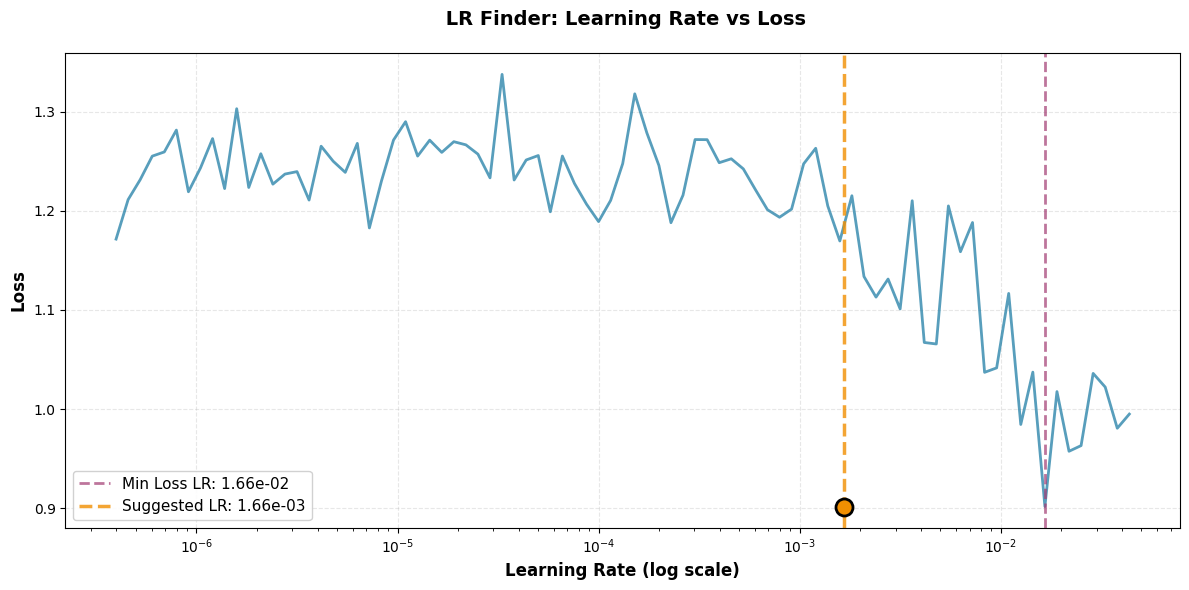


 RESULTADOS DEL LR FINDER:
  LR con pérdida mínima:  1.66e-02
  LR sugerido (1/10):     1.66e-03
  LR actual en CONFIG:    1.45e-03

 RECOMENDACIÓN:
   Considera actualizar CONFIG['LEARNING_RATE'] a: 1.66e-03
   para potencialmente mejorar la convergencia del modelo.

 LR Finder completado exitosamente


In [15]:
# ==========================================
# EJECUCIÓN DEL LR FINDER
# ==========================================

# Crear un modelo temporal para LR Finder (no afecta el modelo principal)
lr_finder_builder = SentimentRNNModel(
    vocab_size=actual_vocab_size,
    embedding_dim=CONFIG['EMBEDDING_DIM'],
    max_length=CONFIG['MAX_SEQUENCE_LENGTH'],
    lstm_units=CONFIG['LSTM_UNITS'],
    dense_units=CONFIG['DENSE_UNITS'],
    dropout_rate=CONFIG['DROPOUT_RATE'],
    spatial_dropout=CONFIG['SPATIAL_DROPOUT'],
    bidirectional=CONFIG['BIDIRECTIONAL']
)

lr_finder_model = lr_finder_builder.build_model()
lr_finder_builder.compile_model(learning_rate=1e-7)  # Empezar con LR muy bajo
lr_finder_model.build(input_shape=(None, CONFIG['MAX_SEQUENCE_LENGTH']))

print(" Modelo temporal creado\n")

# Crear instancia de LR Finder
lr_finder = LRFinder(
    model=lr_finder_model,
    min_lr=1e-7,
    max_lr=1e-1,
    steps=100
)

# Usar un subset de datos para rapidez (máximo 5000 samples)
subset_size = min(5000, len(X_train_padded))
X_subset = X_train_padded[:subset_size]
y_subset = y_train[:subset_size]

print(f" Configuración del LR Finder:")
print(f"   • LR mínimo: {lr_finder.min_lr:.2e}")
print(f"   • LR máximo: {lr_finder.max_lr:.2e}")
print(f"   • Pasos: {lr_finder.steps}")
print(f"   • Samples usados: {subset_size:,}")
print(f"   • Batch size: {CONFIG['BATCH_SIZE']}")
print(f"\n{'='*60}\n")

# Ejecutar la búsqueda
lrs, losses = lr_finder.find(X_subset, y_subset, batch_size=CONFIG['BATCH_SIZE'])

print(f" Búsqueda completada")
print(f"   • LRs evaluados: {len(lrs)}")
print(f"   • Pérdida mínima: {min(losses):.4f}")
print(f"\n{'='*60}\n")

# Visualizar resultados y obtener sugerencia
suggested_lr = lr_finder.plot()

print(f"\n{'='*60}")
print(" LR Finder completado exitosamente")
print(f"{'='*60}")

---

# CAPÍTULO 3: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO

## 3.1 Configuración de Callbacks

1. **EarlyStopping**: Detiene el entrenamiento si la métrica de validación no mejora, previniendo overfitting
2. **ReduceLROnPlateau**: Reduce la tasa de aprendizaje cuando el aprendizaje se estanca
3. **ModelCheckpoint**: Guarda el mejor modelo basado en la métrica de validación

In [16]:
# ==========================================
# CONFIGURACIÓN DE CALLBACKS
# ==========================================

print("  CONFIGURANDO CALLBACKS")
print("="*60)

# 1. EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['PATIENCE_EARLY_STOP'],
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

# 2. ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=CONFIG['REDUCE_LR_FACTOR'],
    patience=CONFIG['PATIENCE_REDUCE_LR'],
    min_lr=CONFIG['MIN_LR'],
    verbose=1,
    mode='min'
)

# 3. ModelCheckpoint
model_checkpoint = ModelCheckpoint(
    filepath=CONFIG['MODEL_SAVE_PATH'],
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr, model_checkpoint]

print("\n Callbacks configurados:")
print(f"   • EarlyStopping (paciencia: {CONFIG['PATIENCE_EARLY_STOP']} épocas)")
print(f"   • ReduceLROnPlateau (factor: {CONFIG['REDUCE_LR_FACTOR']})")
print(f"   • ModelCheckpoint (guardando en: {CONFIG['MODEL_SAVE_PATH']})")
print(f"\n{'='*60}")

  CONFIGURANDO CALLBACKS

 Callbacks configurados:
   • EarlyStopping (paciencia: 3 épocas)
   • ReduceLROnPlateau (factor: 0.5)
   • ModelCheckpoint (guardando en: sentiment_rnn_w2v_model.keras)



In [17]:
# ==========================================
# ENTRENAMIENTO DEL MODELO
# ==========================================

print(" INICIANDO ENTRENAMIENTO DEL MODELO")
print("="*60)
print(f" Configuración del entrenamiento:")
print(f"   • Épocas máximas: {CONFIG['EPOCHS']}")
print(f"   • Batch size: {CONFIG['BATCH_SIZE']}")
print(f"   • Learning rate: {CONFIG['LEARNING_RATE']}")
print(f"   • Training samples: {len(X_train_padded):,}")
print(f"   • Validation samples: {len(X_val_padded):,}")
print(f"\n{'='*60}\n")

# Entrenar el modelo
history = model.fit(
    X_train_padded,
    y_train,
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    validation_data=(X_val_padded, y_val),
    callbacks=callbacks_list,
    verbose=CONFIG['VERBOSE']
)

print(f"\n{'='*60}")
print(" Entrenamiento completado")
print(f" Épocas entrenadas: {len(history.history['loss'])}")
print("="*60)

 INICIANDO ENTRENAMIENTO DEL MODELO
 Configuración del entrenamiento:
   • Épocas máximas: 30
   • Batch size: 32
   • Learning rate: 0.00145
   • Training samples: 40,000
   • Validation samples: 5,000


Epoch 1/30
1249/1250 [============================>.] - ETA: 0s - loss: 0.6172 - accuracy: 0.7538 - precision: 0.7524 - recall: 0.7565 - auc: 0.8318
Epoch 1: val_accuracy improved from -inf to 0.80560, saving model to sentiment_rnn_w2v_model.keras
1250/1250 [==============================] - 50s 37ms/step - loss: 0.6170 - accuracy: 0.7538 - precision: 0.7524 - recall: 0.7566 - auc: 0.8318 - val_loss: 0.4855 - val_accuracy: 0.8056 - val_precision: 0.7361 - val_recall: 0.9528 - val_auc: 0.9236 - lr: 0.0014
Epoch 2/30
1249/1250 [============================>.] - ETA: 0s - loss: 0.3698 - accuracy: 0.8491 - precision: 0.8445 - recall: 0.8557 - auc: 0.9216
Epoch 2: val_accuracy improved from 0.80560 to 0.86460, saving model to sentiment_rnn_w2v_model.keras
1250/1250 [=======================

In [18]:
# ==========================================
# GUARDADO DEL MODELO Y ARTEFACTOS (CON WORD2VEC)         
# ==========================================

print("GUARDANDO MODELO Y ARTEFACTOS")
print("="*60)

# 1. Guardar el modelo completo
model.save(CONFIG['MODEL_SAVE_PATH'])
print(f"Modelo guardado en: {CONFIG['MODEL_SAVE_PATH']}")

# 2. Guardar el tokenizer
with open(CONFIG['TOKENIZER_SAVE_PATH'], 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Tokenizer guardado en: {CONFIG['TOKENIZER_SAVE_PATH']}")

# 3. Guardar Word2Vec model (ya guardado antes, pero confirmamos)
w2v_handler.save_model(CONFIG['W2V_MODEL_PATH'])

# 4. Guardar embedding_matrix (opcional pero recomendado)
np.save('embedding_matrix.npy', embedding_matrix)
print(f"Embedding matrix guardada en: embedding_matrix.npy")

# 5. Guardar la configuración
config_to_save = {
    'vocab_size': actual_vocab_size,
    'max_sequence_length': CONFIG['MAX_SEQUENCE_LENGTH'],
    'embedding_dim': CONFIG['EMBEDDING_DIM'],
    'class_names': CLASS_NAMES,
    'w2v_trainable': CONFIG['W2V_TRAINABLE'],
    'w2v_vector_size': CONFIG['W2V_VECTOR_SIZE'],
    **CONFIG
}

with open(CONFIG['CONFIG_SAVE_PATH'], 'w') as f:
    json.dump(config_to_save, f, indent=4)
print(f"Configuración guardada en: {CONFIG['CONFIG_SAVE_PATH']}")

# 6. Guardar el historial de entrenamiento
with open(CONFIG['HISTORY_SAVE_PATH'], 'wb') as f:
    pickle.dump(history.history, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Historial guardado en: {CONFIG['HISTORY_SAVE_PATH']}")

print(f"\n{'='*60}")
print("Todos los artefactos guardados correctamente")
print("="*60)

GUARDANDO MODELO Y ARTEFACTOS
Modelo guardado en: sentiment_rnn_w2v_model.keras
Tokenizer guardado en: tokenizer_w2v.pickle
Modelo Word2Vec guardado en: word2vec_model.model
Embedding matrix guardada en: embedding_matrix.npy
Configuración guardada en: model_config_w2v.json
Historial guardado en: training_history_w2v.pickle

Todos los artefactos guardados correctamente


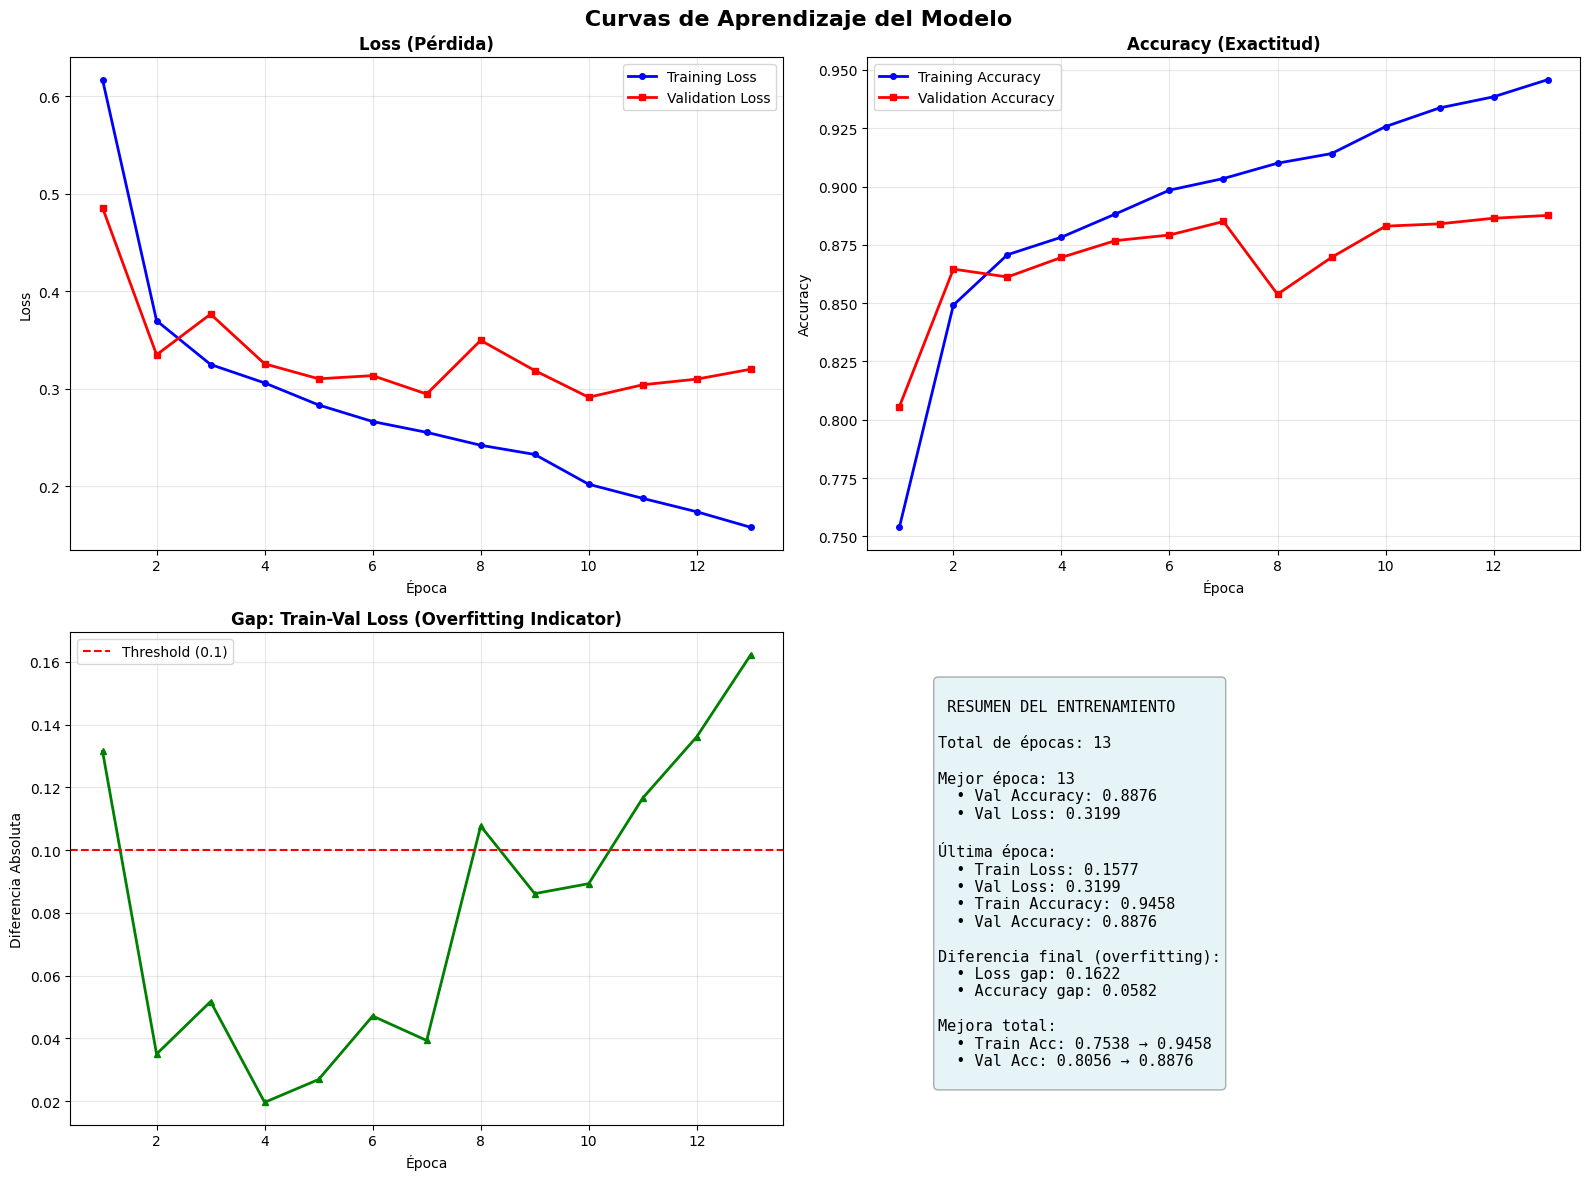

In [19]:
# ==========================================
# CURVAS DE APRENDIZAJE
# ==========================================

# Extraer métricas del historial
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(train_loss) + 1)

# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Curvas de Aprendizaje del Modelo', fontsize=16, fontweight='bold')

# 1. Loss (Pérdida)
ax1 = axes[0, 0]
ax1.plot(epochs_range, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=4)
ax1.plot(epochs_range, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=4)
ax1.set_title('Loss (Pérdida)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Accuracy (Precisión)
ax2 = axes[0, 1]
ax2.plot(epochs_range, train_acc, 'b-o', label='Training Accuracy', linewidth=2, markersize=4)
ax2.plot(epochs_range, val_acc, 'r-s', label='Validation Accuracy', linewidth=2, markersize=4)
ax2.set_title('Accuracy (Exactitud)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Gap entre Train y Validation Loss
ax3 = axes[1, 0]
gap_loss = [abs(t - v) for t, v in zip(train_loss, val_loss)]
ax3.plot(epochs_range, gap_loss, 'g-^', linewidth=2, markersize=4)
ax3.set_title('Gap: Train-Val Loss (Overfitting Indicator)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Época')
ax3.set_ylabel('Diferencia Absoluta')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0.1, color='r', linestyle='--', label='Threshold (0.1)')
ax3.legend()

# 4. Tabla de resumen
ax4 = axes[1, 1]
ax4.axis('off')

best_epoch = np.argmax(val_acc) + 1
best_val_acc = max(val_acc)
best_val_loss = val_loss[best_epoch - 1]

summary_text = f"""
 RESUMEN DEL ENTRENAMIENTO

Total de épocas: {len(train_loss)}

Mejor época: {best_epoch}
  • Val Accuracy: {best_val_acc:.4f}
  • Val Loss: {best_val_loss:.4f}

Última época:
  • Train Loss: {train_loss[-1]:.4f}
  • Val Loss: {val_loss[-1]:.4f}
  • Train Accuracy: {train_acc[-1]:.4f}
  • Val Accuracy: {val_acc[-1]:.4f}

Diferencia final (overfitting):
  • Loss gap: {abs(train_loss[-1] - val_loss[-1]):.4f}
  • Accuracy gap: {abs(train_acc[-1] - val_acc[-1]):.4f}

Mejora total:
  • Train Acc: {train_acc[0]:.4f} → {train_acc[-1]:.4f}
  • Val Acc: {val_acc[0]:.4f} → {val_acc[-1]:.4f}
"""

ax4.text(0.1, 0.9, summary_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.show()

EVALUACION EN TEST SET
Generando predicciones en test set...

METRICAS EN TEST SET
  Accuracy:  0.8924 (89.24%)
  Precision: 0.8727
  Recall:    0.9188
  F1-Score:  0.8952
  ROC-AUC:   0.9592


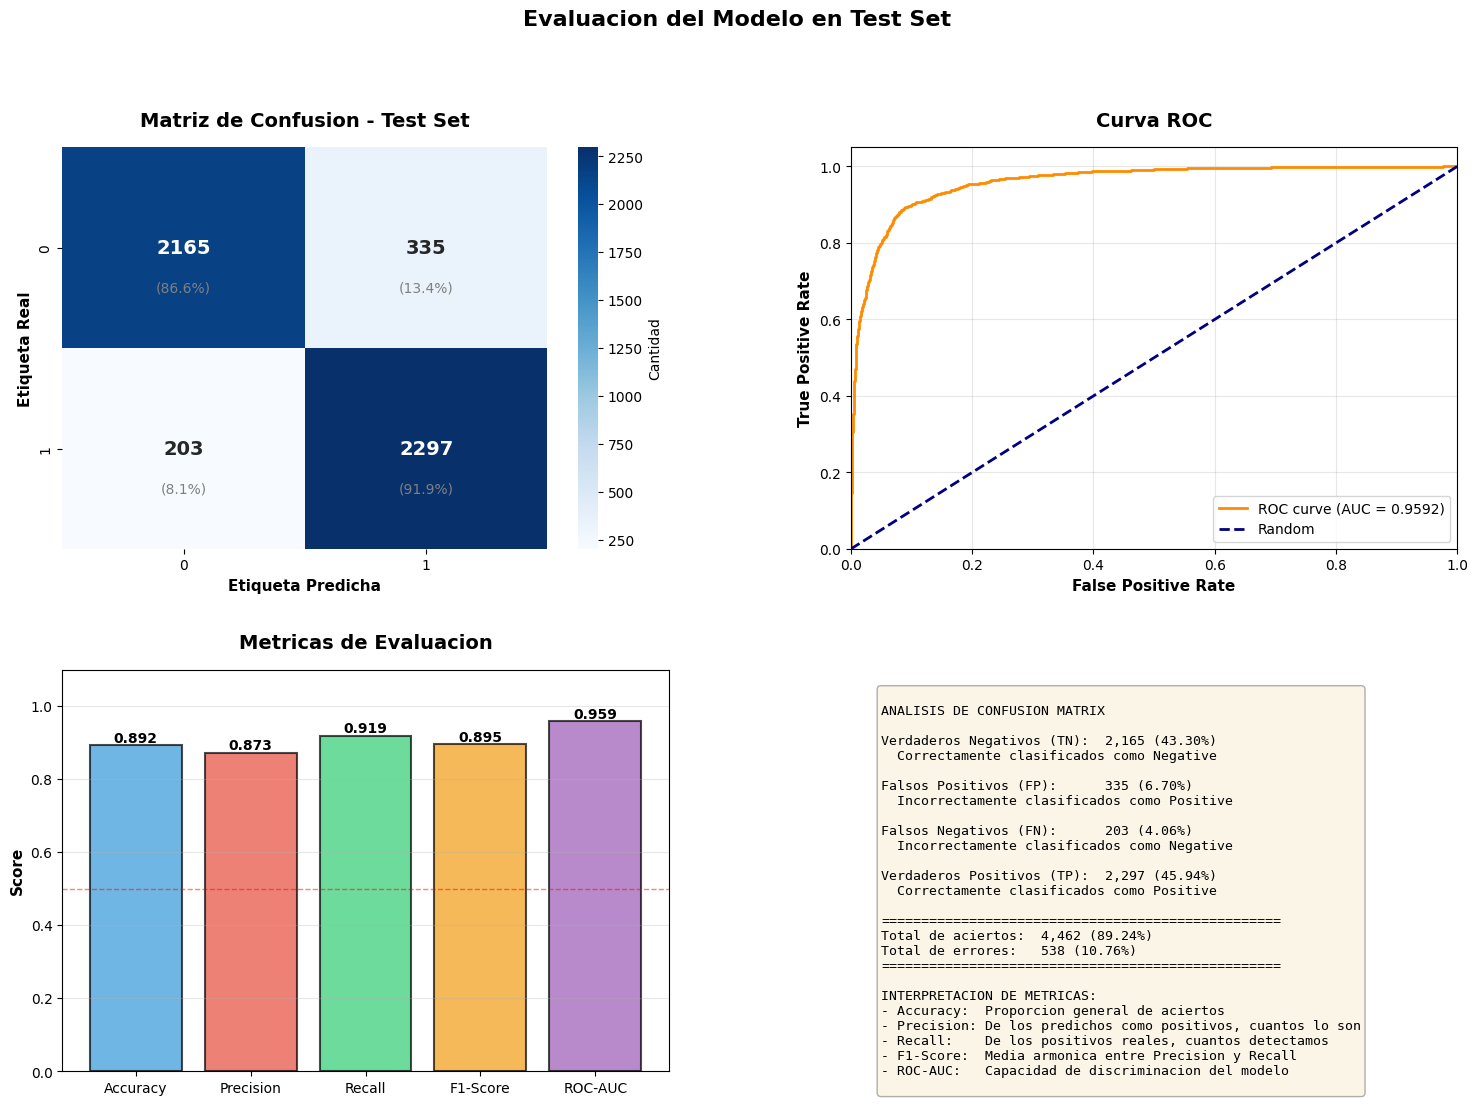

In [20]:
# ==========================================
# EVALUACION EN TEST SET - VERSION OPTIMIZADA
# ==========================================

class ModelEvaluator:
    """
    Clase para evaluar modelos de clasificacion binaria en conjunto de test.
    Aplica Single Responsibility Principle y Interface Segregation.
    """
    
    def __init__(self, model, X_test, y_test, batch_size=32, class_names=None):
        """
        Inicializa el evaluador con modelo y datos de test.
        
        Args:
            model: Modelo de Keras entrenado
            X_test: Datos de entrada para test
            y_test: Etiquetas verdaderas
            batch_size: Tamaño del batch para predicciones
            class_names: Nombres de las clases (lista de 2 elementos)
        """
        self.model = model
        self.X_test = X_test
        self.y_test = y_test
        self.batch_size = batch_size
        self.class_names = class_names or ['Clase 0', 'Clase 1']
        
        self.y_pred = None
        self.y_pred_proba = None
        self.metrics = {}
        self.confusion_matrix = None
    
    def _generate_predictions(self):
        """Genera predicciones del modelo (DRY)."""
        print("Generando predicciones en test set...")
        self.y_pred_proba = self.model.predict(
            self.X_test, 
            batch_size=self.batch_size, 
            verbose=0
        )
        self.y_pred = (self.y_pred_proba > 0.5).astype(int).flatten()
    
    def _calculate_metrics(self):
        """Calcula metricas de evaluacion (DRY)."""
        self.metrics = {
            'accuracy': accuracy_score(self.y_test, self.y_pred),
            'precision': precision_score(self.y_test, self.y_pred),
            'recall': recall_score(self.y_test, self.y_pred),
            'f1': f1_score(self.y_test, self.y_pred),
            'roc_auc': roc_auc_score(self.y_test, self.y_pred_proba)
        }
        self.confusion_matrix = confusion_matrix(self.y_test, self.y_pred)
    
    def _print_metrics_summary(self):
        """Imprime resumen de metricas (DRY)."""
        print("\n" + "="*60)
        print("METRICAS EN TEST SET")
        print("="*60)
        print(f"  Accuracy:  {self.metrics['accuracy']:.4f} ({self.metrics['accuracy']*100:.2f}%)")
        print(f"  Precision: {self.metrics['precision']:.4f}")
        print(f"  Recall:    {self.metrics['recall']:.4f}")
        print(f"  F1-Score:  {self.metrics['f1']:.4f}")
        print(f"  ROC-AUC:   {self.metrics['roc_auc']:.4f}")
        print("="*60)
    
    def _plot_confusion_matrix(self, ax):
        """
        Plotea matriz de confusion (DRY: metodo reutilizable).
        
        Args:
            ax: Eje de matplotlib donde plotear
        """
        sns.heatmap(
            self.confusion_matrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=self.class_names,
            yticklabels=self.class_names,
            cbar_kws={'label': 'Cantidad'},
            ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'}
        )
        
        ax.set_title('Matriz de Confusion - Test Set', fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel('Etiqueta Real', fontsize=11, fontweight='bold')
        ax.set_xlabel('Etiqueta Predicha', fontsize=11, fontweight='bold')
        
        # Agregar porcentajes
        for i in range(2):
            for j in range(2):
                percentage = self.confusion_matrix[i, j] / self.confusion_matrix[i].sum() * 100
                ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                       ha='center', va='center', fontsize=10, color='gray')
    
    def _plot_roc_curve(self, ax):
        """
        Plotea curva ROC (DRY: metodo reutilizable).
        
        Args:
            ax: Eje de matplotlib donde plotear
        """
        fpr, tpr, _ = roc_curve(self.y_test, self.y_pred_proba)
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
        ax.set_title('Curva ROC', fontsize=14, fontweight='bold', pad=15)
        ax.legend(loc="lower right")
        ax.grid(True, alpha=0.3)
    
    def _plot_metrics_bars(self, ax):
        """
        Plotea barras de metricas principales (DRY).
        
        Args:
            ax: Eje de matplotlib donde plotear
        """
        metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
        values = [self.metrics[m] for m in metrics_to_plot]
        labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
        
        colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
        bars = ax.bar(labels, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
        
        ax.set_ylim([0, 1.1])
        ax.set_ylabel('Score', fontsize=11, fontweight='bold')
        ax.set_title('Metricas de Evaluacion', fontsize=14, fontweight='bold', pad=15)
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')
        
        # Agregar valores sobre las barras
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    def _create_summary_table(self, ax):
        """
        Crea tabla de resumen con analisis de confusion matrix (DRY).
        
        Args:
            ax: Eje de matplotlib donde crear la tabla
        """
        ax.axis('off')
        
        tn, fp, fn, tp = self.confusion_matrix.ravel()
        total_samples = len(self.y_test)
        total_correct = tn + tp
        total_errors = fp + fn
        
        summary_text = f"""
ANALISIS DE CONFUSION MATRIX

Verdaderos Negativos (TN):  {tn:,} ({tn/total_samples*100:.2f}%)
  Correctamente clasificados como {self.class_names[0]}

Falsos Positivos (FP):      {fp:,} ({fp/total_samples*100:.2f}%)
  Incorrectamente clasificados como {self.class_names[1]}

Falsos Negativos (FN):      {fn:,} ({fn/total_samples*100:.2f}%)
  Incorrectamente clasificados como {self.class_names[0]}

Verdaderos Positivos (TP):  {tp:,} ({tp/total_samples*100:.2f}%)
  Correctamente clasificados como {self.class_names[1]}

{'='*50}
Total de aciertos:  {total_correct:,} ({total_correct/total_samples*100:.2f}%)
Total de errores:   {total_errors:,} ({total_errors/total_samples*100:.2f}%)
{'='*50}

INTERPRETACION DE METRICAS:
- Accuracy:  Proporcion general de aciertos
- Precision: De los predichos como positivos, cuantos lo son
- Recall:    De los positivos reales, cuantos detectamos
- F1-Score:  Media armonica entre Precision y Recall
- ROC-AUC:   Capacidad de discriminacion del modelo
"""
        
        ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, 
                fontsize=9.5, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    def evaluate(self, figsize=(18, 12)):
        """
        Ejecuta evaluacion completa y genera visualizaciones.
        Open/Closed Principle: Abierto para extension.
        
        Args:
            figsize: Tamaño de la figura de visualizacion
        """
        # Generar predicciones y calcular metricas
        self._generate_predictions()
        self._calculate_metrics()
        self._print_metrics_summary()
        
        # Crear visualizaciones
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # 1. Matriz de confusion (OBLIGATORIA)
        ax1 = fig.add_subplot(gs[0, 0])
        self._plot_confusion_matrix(ax1)
        
        # 2. Curva ROC (Alta relevancia para clasificacion)
        ax2 = fig.add_subplot(gs[0, 1])
        self._plot_roc_curve(ax2)
        
        # 3. Barras de metricas (Vision general)
        ax3 = fig.add_subplot(gs[1, 0])
        self._plot_metrics_bars(ax3)
        
        # 4. Tabla de resumen (Interpretacion)
        ax4 = fig.add_subplot(gs[1, 1])
        self._create_summary_table(ax4)
        
        fig.suptitle('Evaluacion del Modelo en Test Set', 
                     fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()
        
        return self.metrics


# Ejecutar evaluacion
print("="*60)
print("EVALUACION EN TEST SET")
print("="*60)

evaluator = ModelEvaluator(
    model=model,
    X_test=X_test_padded,
    y_test=y_test,
    batch_size=CONFIG['BATCH_SIZE'],
    class_names=CLASS_NAMES
)

test_metrics = evaluator.evaluate()

In [21]:
# ==========================================
# RESUMEN EJECUTIVO DE EVALUACION
# ==========================================

def print_evaluation_summary(metrics, confusion_matrix, class_names):
    """
    Imprime resumen ejecutivo de la evaluacion (DRY: funcion reutilizable).
    
    Args:
        metrics: Diccionario con metricas calculadas
        confusion_matrix: Matriz de confusion numpy array
        class_names: Lista con nombres de las clases
    """
    tn, fp, fn, tp = confusion_matrix.ravel()
    
    print("\n" + "="*70)
    print(" RESUMEN EJECUTIVO - EVALUACION EN TEST SET")
    print("="*70)
    
    # Metricas principales
    print("\nMETRICAS PRINCIPALES:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    # Analisis de errores
    print("\nANALISIS DE ERRORES:")
    total_errors = fp + fn
    total_samples = tn + fp + fn + tp
    print(f"  Total de errores: {total_errors} ({total_errors/total_samples*100:.2f}%)")
    print(f"    - Falsos Positivos: {fp} ({fp/total_samples*100:.2f}%)")
    print(f"    - Falsos Negativos: {fn} ({fn/total_samples*100:.2f}%)")
    
    # Balance de precision-recall
    print("\nBALANCE PRECISION-RECALL:")
    print(f"  Precision: {metrics['precision']:.4f} (De los predichos +, cuantos son reales +)")
    print(f"  Recall:    {metrics['recall']:.4f} (De los reales +, cuantos detectamos)")
    
    # Diagnostico automatico
    print("\nDIAGNOSTICO:")
    if metrics['accuracy'] >= 0.90 and metrics['f1'] >= 0.90:
        diagnosis = "EXCELENTE: Modelo con alto desempeno en todas las metricas"
    elif metrics['accuracy'] >= 0.85 and metrics['f1'] >= 0.85:
        diagnosis = "BUENO: Modelo con desempeno solido y confiable"
    elif metrics['accuracy'] >= 0.75 and metrics['f1'] >= 0.75:
        diagnosis = "ACEPTABLE: Modelo funcional pero con espacio de mejora"
    elif metrics['accuracy'] >= 0.60:
        diagnosis = "INSUFICIENTE: Modelo requiere optimizacion"
    else:
        diagnosis = "CRITICO: Modelo no supera baseline, revisar arquitectura/datos"
    
    print(f"  {diagnosis}")
    
    # Recomendaciones basadas en metricas
    print("\nRECOMENDACIONES:")
    if metrics['precision'] < 0.80 and metrics['recall'] >= 0.80:
        print("  - Precision baja: Muchos falsos positivos. Ajustar threshold o regularizacion")
    elif metrics['recall'] < 0.80 and metrics['precision'] >= 0.80:
        print("  - Recall bajo: Muchos falsos negativos. Revisar balanceo de clases")
    elif metrics['precision'] < 0.80 and metrics['recall'] < 0.80:
        print("  - Precision y Recall bajos: Revisar arquitectura y preprocesamiento")
    else:
        print("  - Modelo bien balanceado. Considerar fine-tuning para optimizar")
    
    print("="*70)


# Ejecutar resumen
print_evaluation_summary(test_metrics, evaluator.confusion_matrix, CLASS_NAMES)      


 RESUMEN EJECUTIVO - EVALUACION EN TEST SET

METRICAS PRINCIPALES:
  Accuracy:  0.8924 (89.24%)
  F1-Score:  0.8952
  ROC-AUC:   0.9592

ANALISIS DE ERRORES:
  Total de errores: 538 (10.76%)
    - Falsos Positivos: 335 (6.70%)
    - Falsos Negativos: 203 (4.06%)

BALANCE PRECISION-RECALL:
  Precision: 0.8727 (De los predichos +, cuantos son reales +)
  Recall:    0.9188 (De los reales +, cuantos detectamos)

DIAGNOSTICO:
  BUENO: Modelo con desempeno solido y confiable

RECOMENDACIONES:
  - Modelo bien balanceado. Considerar fine-tuning para optimizar


In [22]:
# ==========================================
# ANÁLISIS CUALITATIVO -  EJEMPLOS ALEATORIOS
# ==========================================

print(" ANÁLISIS CUALITATIVO:  RESEÑAS ALEATORIAS DEL TEST SET")
print("="*80)
size_s = 30
np.random.seed(CONFIG['RANDOM_SEED'])
random_indices = np.random.choice(len(X_test), size=size_s, replace=False)

comparison_data = []

for i, idx in enumerate(random_indices, 1):
    original_text = X_test[idx]
    true_label = y_test[idx]
    pred_label = evaluator.y_pred[idx]
    pred_proba = evaluator.y_pred_proba[idx][0]
    
    is_correct = "correcto" if true_label == pred_label else "incorrecto"
    
    text_preview = original_text[:100] + "..." if len(original_text) > 100 else original_text
    
    comparison_data.append({
        '#': i,
        'Reseña (preview)': text_preview,
        'Etiqueta Real': CLASS_NAMES[true_label],
        'Etiqueta Predicha': CLASS_NAMES[pred_label],
        'Probabilidad': f'{pred_proba:.4f}',
        'Correcto': is_correct
    })
    
    print(f"\n{'='*80}")
    print(f"EJEMPLO {i} {is_correct}")
    print(f"{'='*80}")
    print(f" Reseña completa:")
    print(f"{original_text[:300]}..." if len(original_text) > 300 else original_text)
    print(f"\n  Etiqueta Real:      {CLASS_NAMES[true_label]} ({true_label})")
    print(f" Etiqueta Predicha:  {CLASS_NAMES[pred_label]} ({pred_label})")
    print(f" Probabilidad:       {pred_proba:.4f}")
    print(f"  Estado:             {'CORRECTO' if true_label == pred_label else 'INCORRECTO'}")

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(" TABLA COMPARATIVA")
print("="*80)
display(comparison_df)

print(f"\n Análisis cualitativo completado")
print(f" Aciertos en la muestra: {sum([1 for d in comparison_data if d['Correcto'] == 'correcto'])}/{size_s}")


 ANÁLISIS CUALITATIVO:  RESEÑAS ALEATORIAS DEL TEST SET

EJEMPLO 1 correcto
 Reseña completa:
awful confusing bit of crap from south of the border i ve now watched it twice and i still don t really know what was going on it had something to do with a stupid looking aztec mummy a that s the dumbest looking robot i ve ever seen bar none and a woman who is the reincarnation of some ancient azte...

  Etiqueta Real:      Negative (0.0)
 Etiqueta Predicha:  Negative (0)
 Probabilidad:       0.0117
  Estado:             CORRECTO

EJEMPLO 2 correcto
 Reseña completa:
2 outta 5 stars br br i have no idea what the title is supposed even less of an idea of what is supposed to be going on in this movie half the time yet it still kept me sort of interested this is low low budget film making along the lines of el mariachi filmed in 16mm and for what it s worth the sho...

  Etiqueta Real:      Negative (0.0)
 Etiqueta Predicha:  Negative (0)
 Probabilidad:       0.2553
  Estado:             CORRECT

,#,Reseña (preview),Etiqueta Real,Etiqueta Predicha,Probabilidad,Correcto
0,1,awful confusing bit of crap from south of the ...,Negative,Negative,0.0117,correcto
1,2,2 outta 5 stars br br i have no idea what the ...,Negative,Negative,0.2553,correcto
2,3,wait till you watch this one i mean even after...,Negative,Negative,0.0124,correcto
3,4,the bank 1915 chaplin the bank was one of char...,Negative,Positive,0.6364,incorrecto
4,5,the story was well plotted and interesting by ...,Positive,Positive,0.8136,correcto
5,6,this is a terrible terrible film br br first o...,Negative,Negative,0.0067,correcto
6,7,the polar express director robert zemeckis i l...,Negative,Positive,0.7266,incorrecto
7,8,when i first saw this movie i was literally ro...,Negative,Negative,0.0849,correcto
8,9,this allegedly based on a true story tv movie ...,Negative,Negative,0.0367,correcto
9,10,and anyone who watches this film will agree th...,Positive,Positive,0.9783,correcto



 Análisis cualitativo completado
 Aciertos en la muestra: 25/30
